<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=294048956" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, preprocessing
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.], device='cuda:0') cuda


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [6]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090001,2026-01-24,0002082542,2025-09-30,0.000225,NaN,NaN,NaN,-0.000017,-0.000027,0.000064,...,NaN,NaN,NaN,NaN,NaN,BIXI,NASDAQ,NaN,NaN,116
1090002,2026-01-24,0002082844,2025-09-30,0.000197,NaN,NaN,NaN,-0.000034,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,SAC-U,NYSE,NaN,NaN,116
1090003,2026-01-24,0002084563,2025-09-30,0.000295,NaN,NaN,NaN,-0.000036,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,LFAC,NASDAQ,NaN,NaN,116
1090004,2026-01-24,0002088749,2025-09-30,0.000676,NaN,NaN,NaN,-0.000032,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,KBON,NASDAQ,NaN,NaN,116


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [7]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)
snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-01-24 0001905956 2025-09-30    TGL   0.016595     0.004622   
           0001906324 2025-09-28   QDEL   5.675100     3.638700   
           0001907982 2025-09-30   QBTS   0.865820     0.195266   
           0001914605 2025-09-30   ECBK   1.552653     1.383344   
           0001915657 2025-09-30   DINO  17.264000     7.834000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-01-24 0001905956 2025-09-30             -0.010266    NaN  
           0001906324 2025-09-28              0.037000    NaN  
           0001907982 2025-09-30             -0.051593    NaN  
           0001914605 2025-09-30              0.009768    NaN  
           0001915657 2025-09-30              1.167000    NaN  

[456837 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [8]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3399 unique ciks for a total of 574431 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[574431 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Gemini we re-created it to handle our multi-dimensional data.

In [9]:
# Generated by Gemini AI
def batched_corrcoef(t1, t2):
    """
    Computes batched correlation coefficient matrix.
    t1 and t2 are tensors of shape (B, N) where B is the batch size
    and N is the number of observations.
    Returns a tensor of shape (B, 2, 2).
    """
    # Stack the tensors along a new dimension to create a (B, 2, N) tensor
    stacked_tensors = torch.stack([t1, t2], dim=1)

    # Compute covariance for each batch
    # We need to compute covariance for each item in the batch.
    # torch.cov doesn't have a batch dimension argument.
    # We can implement batched covariance manually.
    mean_x = torch.mean(stacked_tensors, dim=2, keepdim=True)
    mx = stacked_tensors - mean_x
    # For batched dot product, we can use matmul
    # mx is (B, 2, N), mx.transpose(-1, -2) is (B, N, 2)
    # cov is (B, 2, 2)
    cov_matrix = torch.matmul(mx, mx.transpose(-1, -2)) / (stacked_tensors.size(2) - 1)

    # Extract diagonal for standard deviation
    std_dev = torch.sqrt(torch.diagonal(cov_matrix, dim1=-2, dim2=-1))
    # std_dev is (B, 2). We need to compute outer product for each batch item.
    # We can do this by unsqueezing and multiplying.
    std_dev_prod = std_dev.unsqueeze(2) * std_dev.unsqueeze(1)

    # Normalize covariance matrix
    corr_matrix = cov_matrix / std_dev_prod
    return corr_matrix

# Create two test tensors of shape 3 samples with 5 features:
t1 = torch.randn(3, 5)
t2 = torch.randn(3, 5)

# Compute batched correlation coefficient
result_vectorized = batched_corrcoef(t1, t2)

print("Shape of the vectorized result:", result_vectorized.shape)
result_vectorized

Shape of the vectorized result: torch.Size([3, 2, 2])


tensor([[[ 1.0000, -0.3096],
         [-0.3096,  1.0000]],

        [[ 1.0000,  0.2357],
         [ 0.2357,  1.0000]],

        [[ 1.0000,  0.1639],
         [ 0.1639,  1.0000]]])

In [10]:
# The correlation coefficient varies from -1 (perfect inverse correlation) to 0 (no correlation) to 1 (perfect correlation)
# In order to be used as a part of a loss function, we have to convert this in a way that 0 means perfect correlation and
# anything above is either no correlation, or even worse - inverse correlation.
def convert_corrcoef_to_loss(corrcoef_matrix):
    """
    Takes a tensor of shape (B, 2, 2) and outputs a tensor of shape (B,)
    """
    # Convert the correlation coefficient 2x2 matrices to scalars,
    # i,e. from shape (B, 2, 2) to shape (B,)
    corrcoefs = corrcoef_matrix.sum(dim=[1,2])/2 - 1
    # If corr = -1 -> return = 2 (worst case)
    # If corr =  0 -> return = 1 (bad case)
    # If corr =  1 -> return = 0 (best case)
    return 1 - corrcoefs
convert_corrcoef_to_loss(result_vectorized)

tensor([1.3096, 0.7643, 0.8361])

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (method get_asset_loss)
4. Finally, the model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [11]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self,df):
        super().__init__()
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        self.print_shape = True
        print('Input shape:',self.ml_input.shape)
        print('Labels shape:',self.labels.shape)
        print('Asset multiplier shape:',self.asmul.shape)
        print('Cash multiplier shape:',self.cashmul.shape)

    def get_adjusted_assets(self):
        adjusted_assets = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        if self.print_shape:
            print('Adjusted assets shape:',adjusted_assets.shape)        
        return adjusted_assets

    def get_asset_loss(self):
        # 1d tensor of length self.len_snapshots
        asset_loss = (self.get_adjusted_assets().sum(dim=0) / self.ml_input[:,:,self.columns['Assets']].sum(dim=0) - 1).abs()
        if self.print_shape:
            print('Asset loss shape:',asset_loss.shape)        
        return asset_loss
    
    def get_total_loss(self):
        y_pred = self()
        corrcoef = batched_corrcoef(y_pred,self.labels)
        corrcoef = convert_corrcoef_to_loss(corrcoef)
        
        if self.print_shape:
            print('Predictions shape:',y_pred.shape)
            print('Labels shape:',self.labels.shape)
            print('Correlation coefficient shape:',corrcoef.shape)
            
        self._corr_loss = corrcoef.sum() + corrcoef.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        self._asset_loss = self.get_asset_loss().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self._asmul_loss = 10 * self.asmul.mean().abs() + self.asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        self._total_loss = self._corr_loss + self._asset_loss + 10 * self._asmul_loss
        
        if self.print_shape:
            self.print_shape = False
        return self._total_loss

    def get_param_state(self):
        param_state = { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }
        for i,value in enumerate([self._corr_loss, self._asset_loss, self._asmul_loss ]):
            i = ['correlation','market_assets','asmul'][i]
            param_state[f"loss_{i}"] = value.item()
        return param_state

    def forward(self):
        fwd = self.get_adjusted_assets()
        fwd -= self.ml_input[:,:,self.columns['Liabilities']]
        fwd += self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        if self.print_shape:
            print('Forward shape:',fwd.shape)
        return fwd

    def get_df(self):
        ret_df = self.df.copy()
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(ret_df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3399, 169, 3])
Labels shape: torch.Size([3399, 169])
Asset multiplier shape: torch.Size([3399])
Cash multiplier shape: torch.Size([169])


device(type='cuda', index=0)

Adjusted assets shape: torch.Size([3399, 169])
Forward shape: torch.Size([3399, 169])
Predictions shape: torch.Size([3399, 169])
Labels shape: torch.Size([3399, 169])
Correlation coefficient shape: torch.Size([3399])
Adjusted assets shape: torch.Size([3399, 169])
Asset loss shape: torch.Size([169])
Epoch [1000/10000], Loss=997.04406240
Epoch [2000/10000], Loss=996.28769074
Epoch [3000/10000], Loss=995.66663971
Epoch [4000/10000], Loss=995.61520507
Epoch [5000/10000], Loss=995.49010725
Epoch [6000/10000], Loss=995.37871596
Epoch [7000/10000], Loss=995.56269467
Epoch [8000/10000], Loss=995.19371448
Epoch [9000/10000], Loss=995.29776807
Epoch [10000/10000], Loss=995.17302148


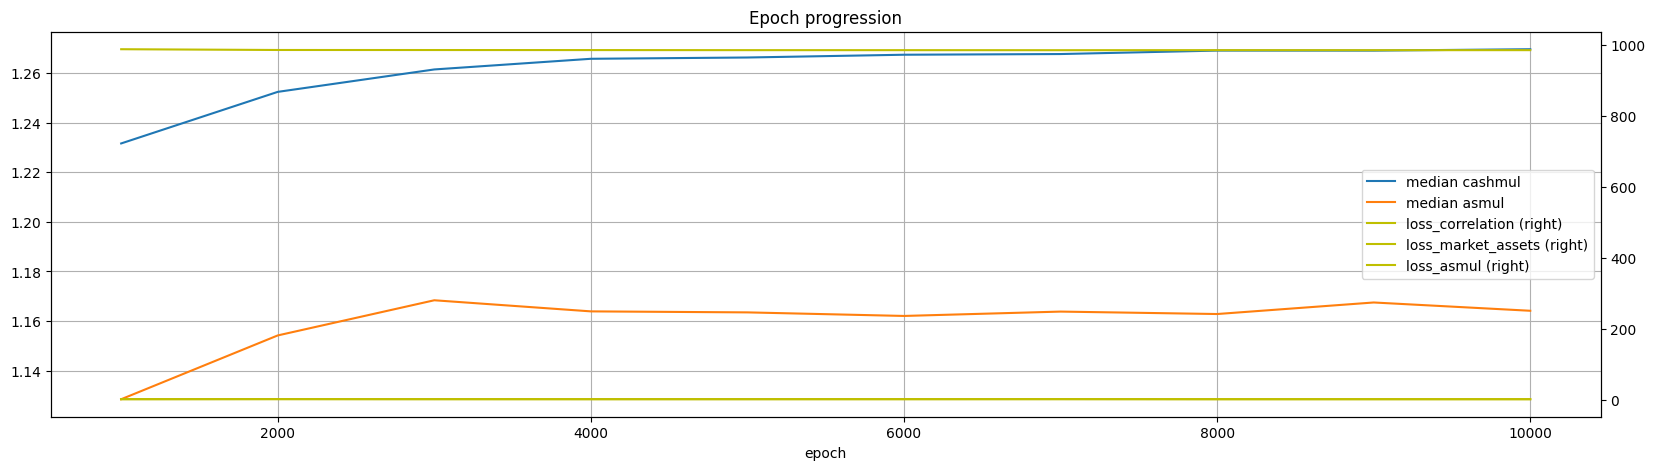

,median cashmul,median asmul,loss_correlation,loss_market_assets,loss_asmul
epoch,,,,,
1000,1.231626,1.128427,986.967285,1.126072,0.895071
2000,1.252431,1.154163,984.816851,1.400211,1.007063
3000,1.261477,1.168351,984.681310,1.146993,0.983834
4000,1.265776,1.163868,984.566378,1.053721,0.999511
5000,1.266297,1.163462,984.361217,1.059613,1.006928
6000,1.267413,1.162026,984.330075,1.129483,0.991916
7000,1.267691,1.163784,984.217453,1.294467,1.005077
8000,1.269086,1.162799,984.387267,0.951942,0.985451
9000,1.269071,1.167457,984.274098,0.978655,1.004501


In [12]:
def model_train(model, num_epochs = 10000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = model.get_total_loss()
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = model.get_param_state()
            param_state['epoch'] = epoch + 1
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [13]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2012-01-01  1.000019 -1.138447  0.768822  
           2012-02-01  1.000019 -1.009673  0.779586  
           2012-03-01  1.000019 -0.932981  0.785996  
           2012-04-01  1.000019 -0.861563  0.832485  
           2012-05-01  1.000019 -0.886716  0.830802  
...                         ...       ...       ...  
0001915657 2025-09-01  0.815274  1.549053  7.823493  
           2025-10-01  0.815274  1.542356  7.816347  
           2025-11-01  0.815274  1.433393  7.913654  
           2025-12-01  0.815274  1.464224  7.949633  
           2026-01-01  0.815274  1.470916  7.957443  

[438464 rows x 7 columns]

In [14]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(a_group):
    (ticker, cik), df = a_group
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    df['slope'] = regressor.coef_[0]
    df['intercept'] = regressor.intercept_
    return df

with Parallel(n_jobs=-1) as p:
    result = pd.concat(p(delayed(line_fit)(i) for i in result.groupby(by=['ticker','cik'])))
    
result = result.reset_index().set_index(['snapshot','cik','date']).sort_index()

# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept
snapshot,cik,date,,,,,,,,,,
2024-07-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,193.25,0.54657,1.258018,176.080198,0.626396,49.111007
2024-08-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,186.98,0.54657,1.500405,214.648874,0.626396,49.111007
2024-09-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,178.50,0.54657,1.523624,254.694112,0.626396,49.111007
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.54657,1.557972,260.776823,0.626396,49.111007
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.54657,1.482519,247.414843,0.626396,49.111007
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.54657,1.736081,330.765185,0.626396,49.111007
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.54657,1.480235,281.145462,0.626396,49.111007
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.54657,1.559416,296.502126,0.626396,49.111007
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.54657,1.480897,294.530055,0.626396,49.111007


Let's examine the achieved correlations using a histogram:

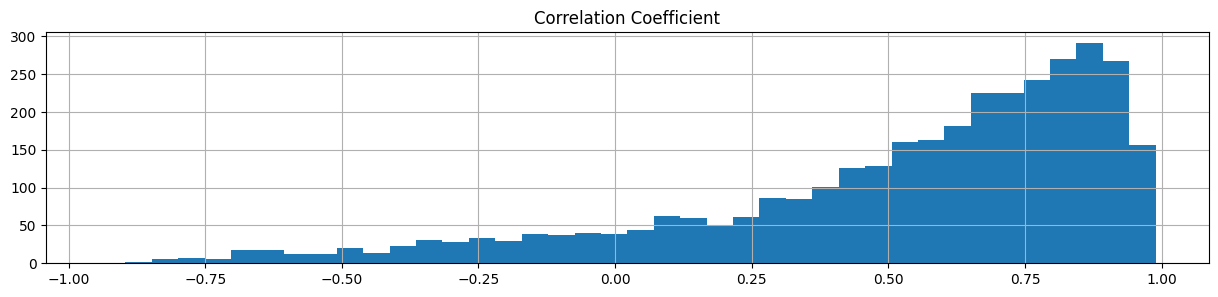

In [15]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.hist(figsize=(15,3),bins=40)
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

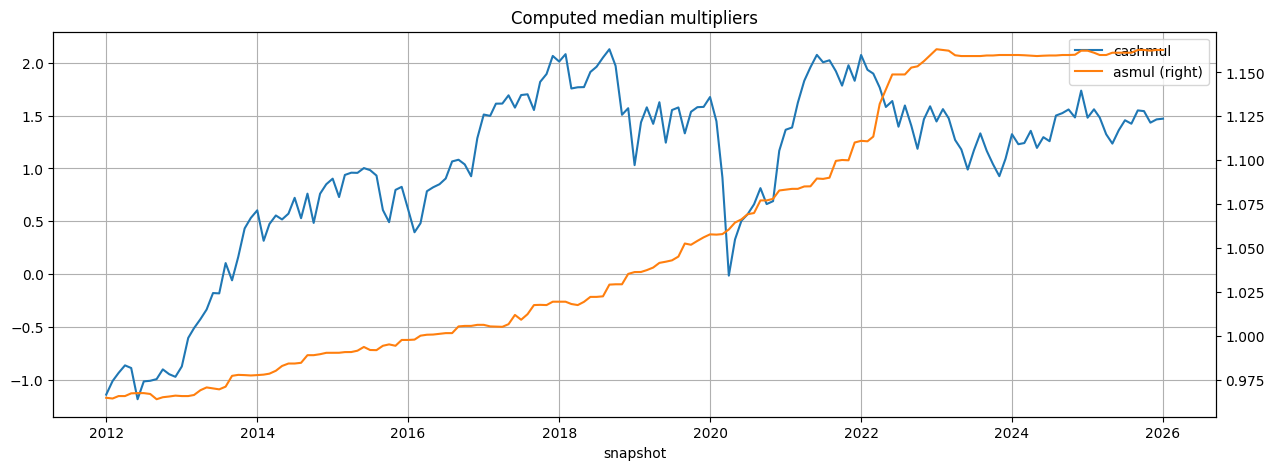

Median asset_multiplier per cik: 1.1641147136688232
Median asset_multiplier per snapshot: 1.0362592935562134


In [16]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [17]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

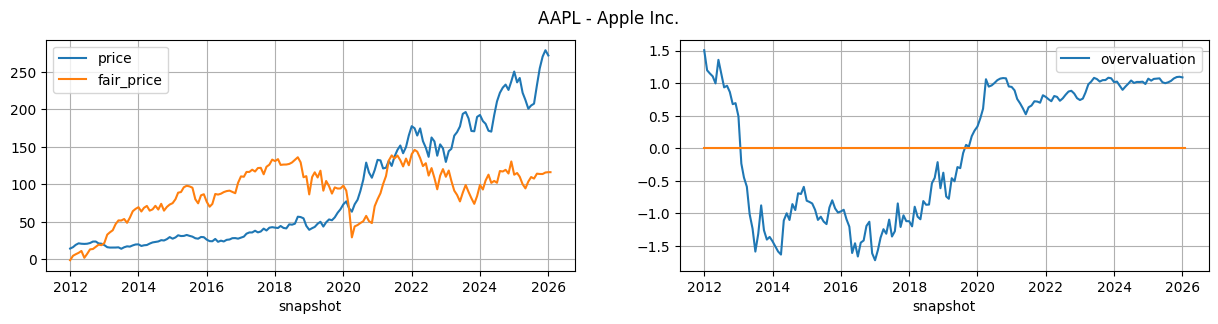

AAPL fair_price = 0.583794 * (0.988650 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -20.128194


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320193,2025-06-28,AAPL,331.495,265.665,108.565,0.988651,1.542356,0.583794,-20.128194,229.513527,113.860378
2025-11-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.988651,1.433393,0.583794,-20.128194,229.453287,113.825211
2025-12-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.988651,1.464224,0.583794,-20.128194,232.890386,115.831768
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.988651,1.470916,0.583794,-20.128194,233.636469,116.267327
2026-01-24,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,0.988651,1.470916,0.583794,-20.128194,233.636469,116.267327


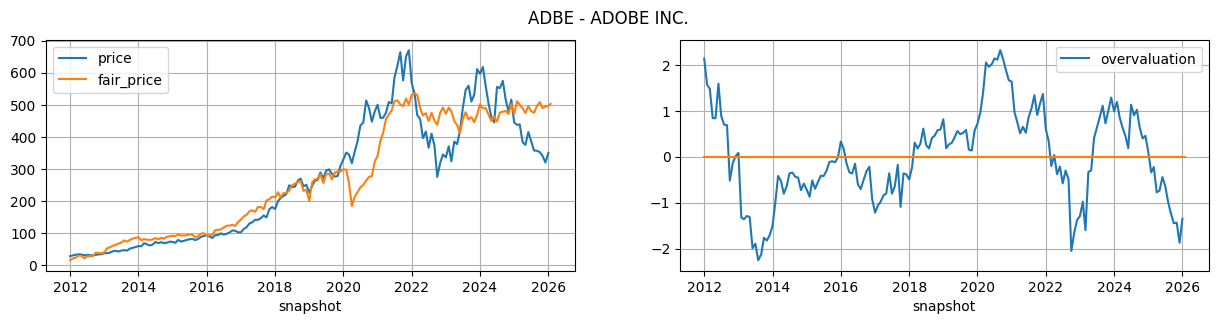

ADBE fair_price = 17.642820 * (1.249893 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -92.555192


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.249893,1.542356,17.64282,-92.555192,34.058181,508.327158
2025-11-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.249893,1.433393,17.64282,-92.555192,32.991218,489.502913
2025-12-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.249893,1.464224,17.64282,-92.555192,33.293114,494.829227
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.249893,1.470916,17.64282,-92.555192,33.358647,495.985397
2026-01-24,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.249893,1.470916,17.64282,-92.555192,33.748616,502.865566


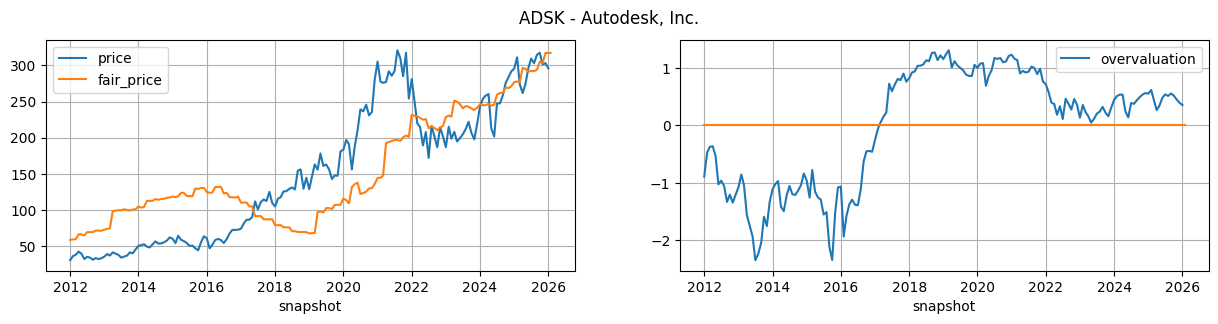

ADSK fair_price = 8.450288 * (4.142869 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -31.240002


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.142869,1.542356,8.450288,-31.240002,39.803015,305.106923
2025-11-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,4.142869,1.433393,8.450288,-31.240002,39.593262,303.334447
2025-12-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.142869,1.464224,8.450288,-31.240002,41.242244,317.268821
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.142869,1.470916,8.450288,-31.240002,41.256666,317.390692
2026-01-24,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,4.142869,1.470916,8.450288,-31.240002,41.256666,317.390692


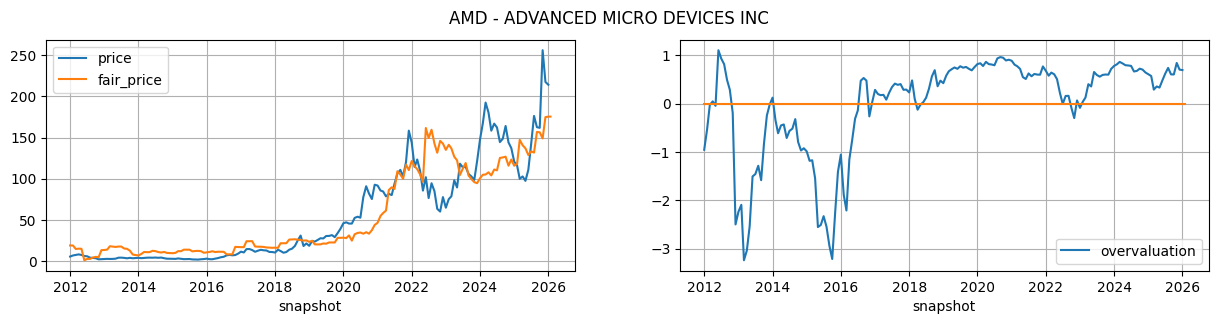

AMD fair_price = 13.879536 * (0.202162 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +52.347484


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.202162,1.542356,13.879536,52.347484,7.492841,156.344641
2025-11-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.202162,1.433393,13.879536,52.347484,6.961429,148.968897
2025-12-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.202162,1.464224,13.879536,52.347484,8.826196,174.850999
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.202162,1.470916,13.879536,52.347484,8.869081,175.446222
2026-01-24,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.202162,1.470916,13.879536,52.347484,8.869081,175.446222


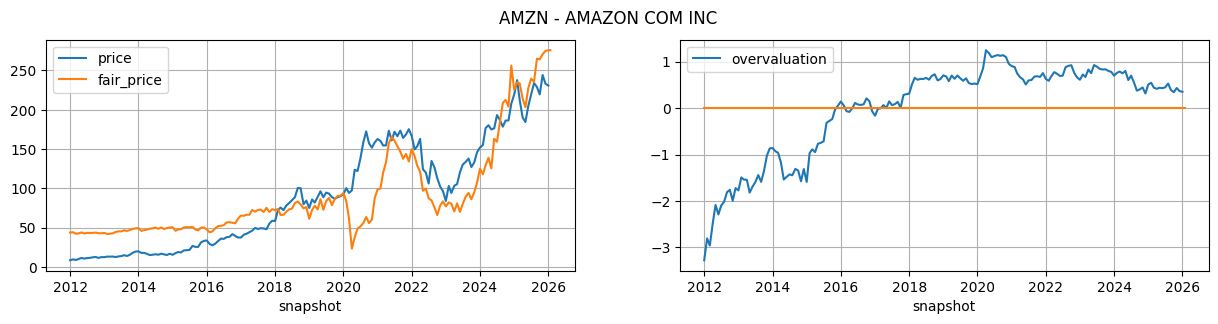

AMZN fair_price = 0.626396 * (0.546569 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +49.111007


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001018724,2025-06-30,AMZN,682.170,348.395,206.735833,0.54657,1.542356,0.626396,49.111007,343.318490,264.164353
2025-11-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.54657,1.433393,0.626396,49.111007,353.626030,270.620955
2025-12-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.54657,1.464224,0.626396,49.111007,360.381103,274.852306
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.54657,1.470916,0.626396,49.111007,361.847411,275.770796
2026-01-24,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.54657,1.470916,0.626396,49.111007,361.847411,275.770796


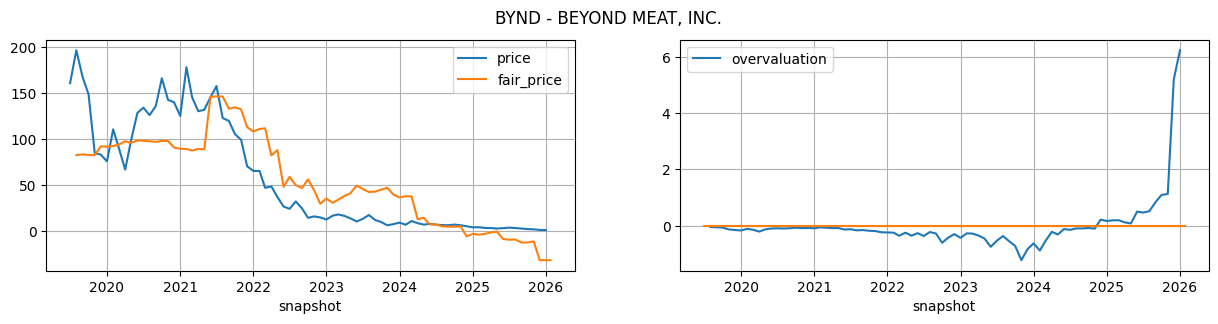

BYND fair_price = 103.129506 * (1.685261 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.779434


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.68526,1.542356,103.129506,25.779434,-0.373205,-12.709053
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.68526,1.433393,103.129506,25.779434,-0.361181,-11.468974
2025-12-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.68526,1.464224,103.129506,25.779434,-0.559224,-31.893037
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.68526,1.470916,103.129506,25.779434,-0.560074,-31.980753
2026-01-24,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.68526,1.470916,103.129506,25.779434,-0.560074,-31.980753


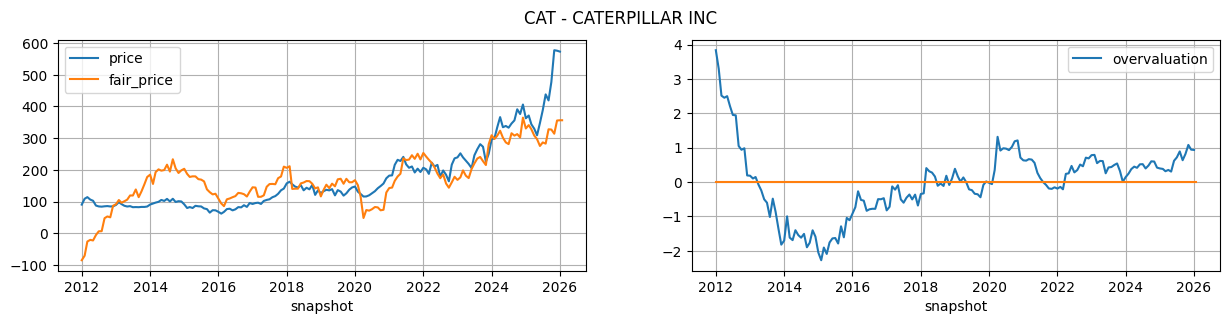

CAT fair_price = 10.582542 * (1.393924 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -432.440142


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.393924,1.542356,10.582542,-432.440142,71.785373,327.231592
2025-11-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.393924,1.433393,10.582542,-432.440142,70.546139,314.117350
2025-12-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.393924,1.464224,10.582542,-432.440142,74.476929,355.715093
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.393924,1.470916,10.582542,-432.440142,74.554166,356.532458
2026-01-24,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.393924,1.470916,10.582542,-432.440142,74.554166,356.532458


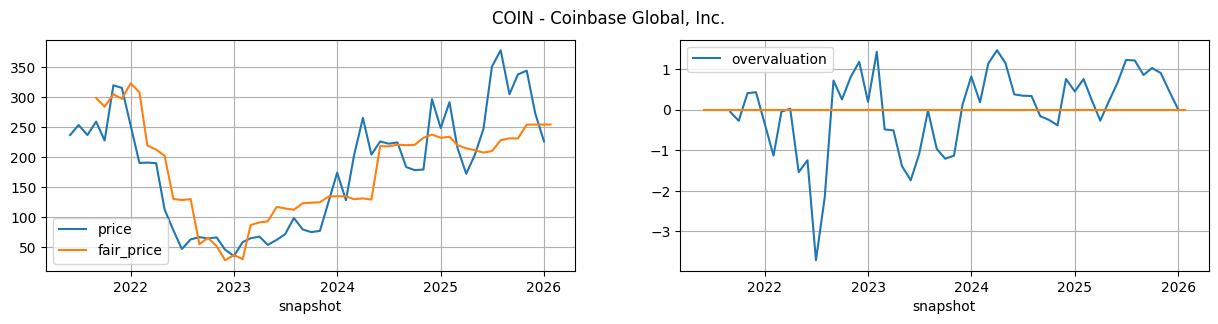

COIN fair_price = 13.344531 * (1.014552 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.808801


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,1.014552,1.542356,13.344531,27.808801,15.223400,230.957928
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014552,1.433393,13.344531,27.808801,16.946509,253.952007
2025-12-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014552,1.464224,13.344531,27.808801,16.956555,254.086070
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014552,1.470916,13.344531,27.808801,16.958736,254.115171
2026-01-24,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.014552,1.470916,13.344531,27.808801,16.958736,254.115171


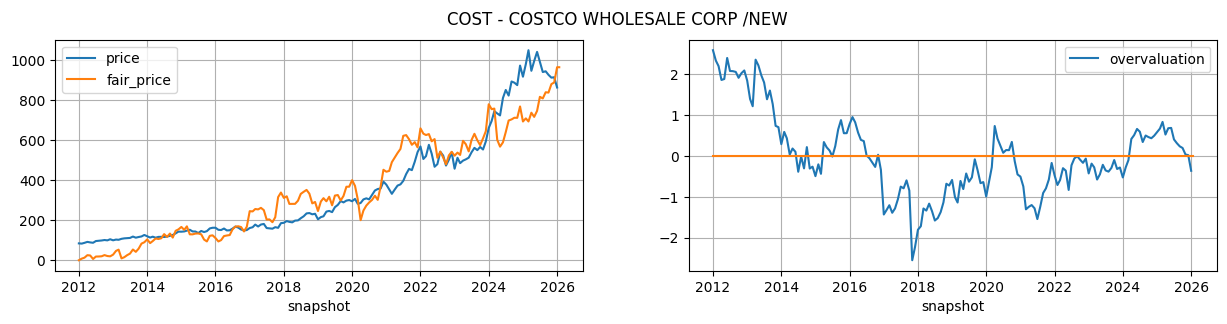

COST fair_price = 19.776274 * (1.092742 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -216.959809


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000909832,2025-05-11,COST,75.482,48.357,12.426,1.092742,1.542356,19.776274,-216.959809,53.290659,836.930848
2025-11-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.092742,1.433393,19.776274,-216.959809,55.428605,879.211461
2025-12-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.092742,1.464224,19.776274,-216.959809,55.839736,887.342102
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.092742,1.470916,19.776274,-216.959809,59.696243,963.609422
2026-01-24,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.092742,1.470916,19.776274,-216.959809,59.696243,963.609422


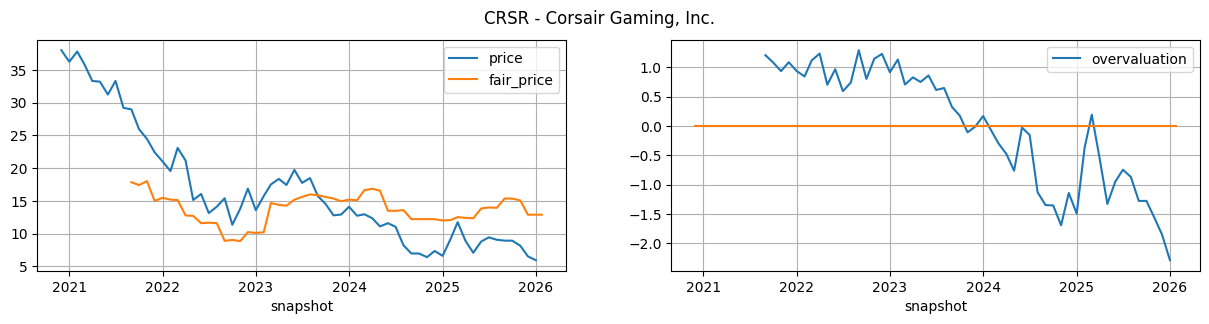

CRSR fair_price = 20.559880 * (1.651070 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -17.538673


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.65107,1.542356,20.55988,-17.538673,1.599314,15.343032
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.65107,1.433393,20.55988,-17.538673,1.585193,15.052696
2025-12-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.65107,1.464224,20.55988,-17.538673,1.479382,12.877243
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.65107,1.470916,20.55988,-17.538673,1.479834,12.886532
2026-01-24,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.65107,1.470916,20.55988,-17.538673,1.479834,12.886532


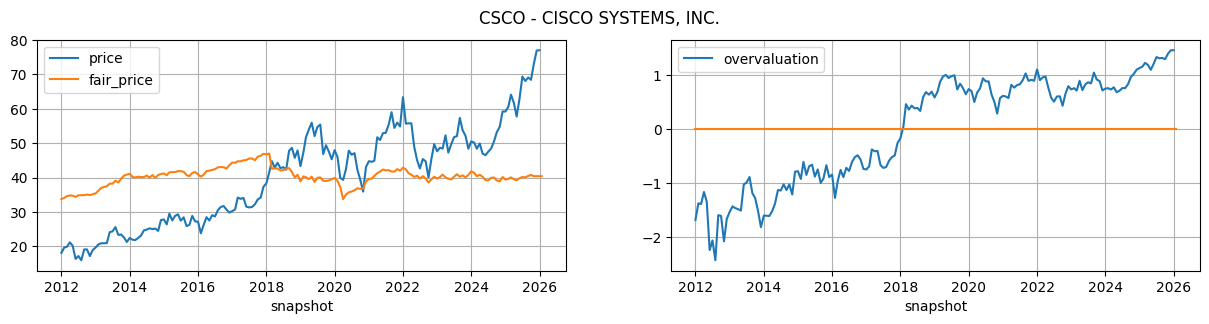

CSCO fair_price = 0.246809 * (0.849231 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.346381


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.849231,1.542356,0.246809,28.346381,50.295976,40.759863
2025-11-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.849231,1.433393,0.246809,28.346381,48.749467,40.378172
2025-12-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.849231,1.464224,0.246809,28.346381,48.738879,40.375558
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.849231,1.470916,0.246809,28.346381,48.830859,40.398260
2026-01-24,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.849231,1.470916,0.246809,28.346381,48.830859,40.398260


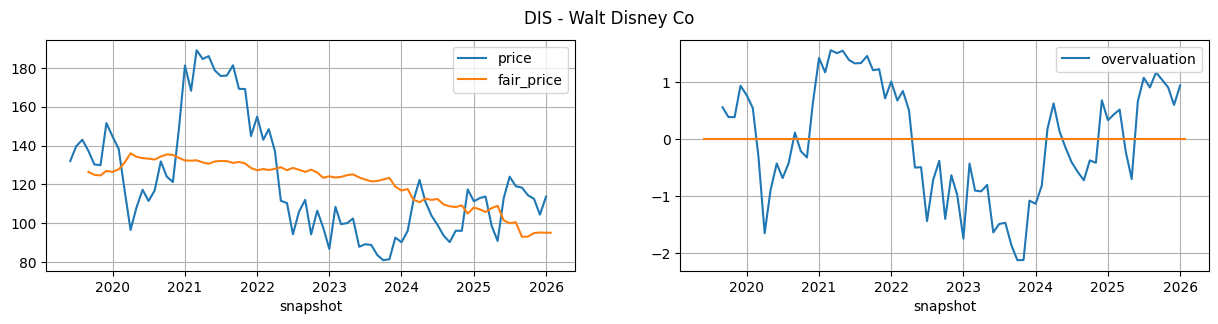

DIS fair_price = -0.865335 * (0.886448 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +193.895816


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.886448,1.542356,-0.865335,193.895816,116.347751,93.216052
2025-11-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,0.886448,1.433393,-0.865335,193.895816,114.261659,95.021221
2025-12-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.886448,1.464224,-0.865335,193.895816,113.944845,95.295371
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.886448,1.470916,-0.865335,193.895816,114.065984,95.190545
2026-01-24,0001744489,2025-09-27,DIS,197.514,87.645,18.101,0.886448,1.470916,-0.865335,193.895816,114.065984,95.190545


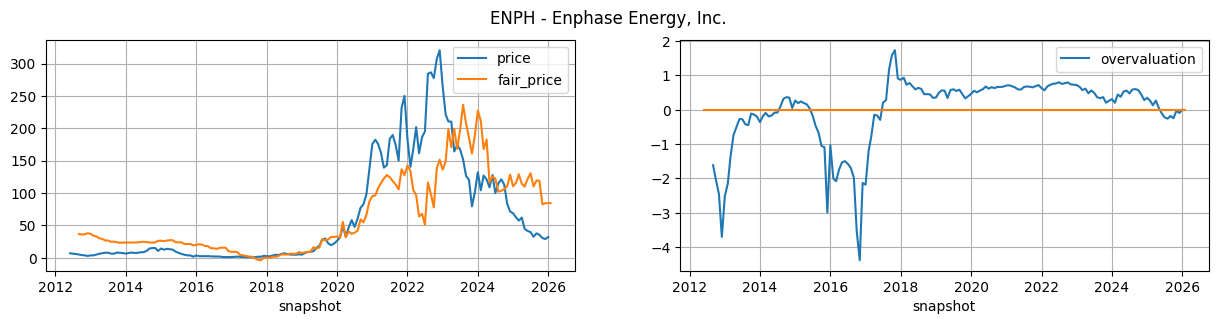

ENPH fair_price = 182.836251 * (0.687933 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +23.017477


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.687933,1.542356,182.836251,23.017477,0.524823,118.974095
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.687933,1.433393,182.836251,23.017477,0.326119,82.643917
2025-12-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.687933,1.464224,182.836251,23.017477,0.334020,84.088420
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.687933,1.470916,182.836251,23.017477,0.335735,84.401975
2026-01-24,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.687933,1.470916,182.836251,23.017477,0.335735,84.401975


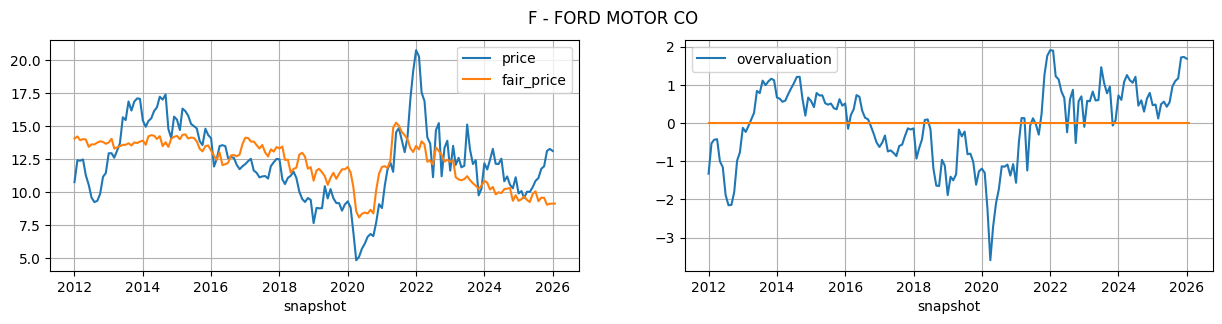

F fair_price = 0.113419 * (0.075848 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +31.895375


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000037996,2025-06-30,F,292.725,247.668,18.526,0.075848,1.542356,0.113419,31.895375,-196.891810,9.564081
2025-11-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.075848,1.433393,0.113419,31.895375,-201.490127,9.042544
2025-12-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.075848,1.464224,0.113419,31.895375,-200.860373,9.113970
2026-01-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.075848,1.470916,0.113419,31.895375,-200.723674,9.129474
2026-01-24,0000037996,2025-09-30,F,300.990,253.598,20.426,0.075848,1.470916,0.113419,31.895375,-200.723674,9.129474


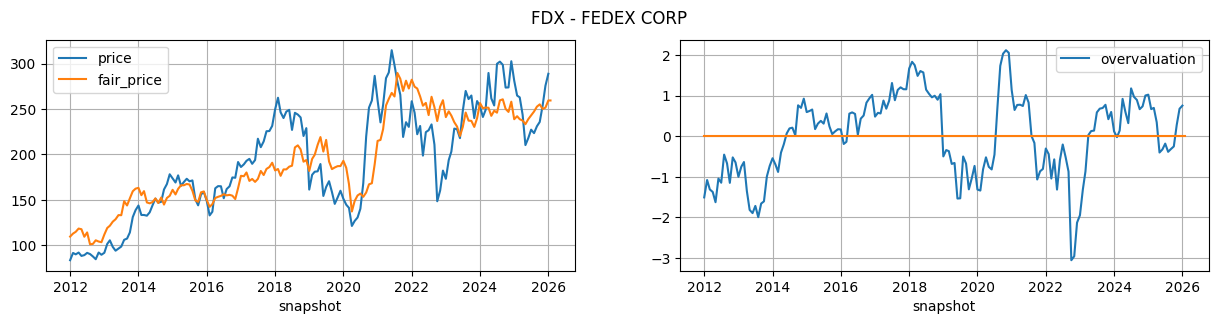

FDX fair_price = 6.111799 * (0.925390 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +54.441927


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.92539,1.542356,6.111799,54.441927,32.842234,255.167045
2025-11-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.92539,1.433393,6.111799,54.441927,32.017931,250.129069
2025-12-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.92539,1.464224,6.111799,54.441927,32.251167,251.554563
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.92539,1.470916,6.111799,54.441927,33.544809,259.461040
2026-01-24,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.92539,1.470916,6.111799,54.441927,33.544809,259.461040


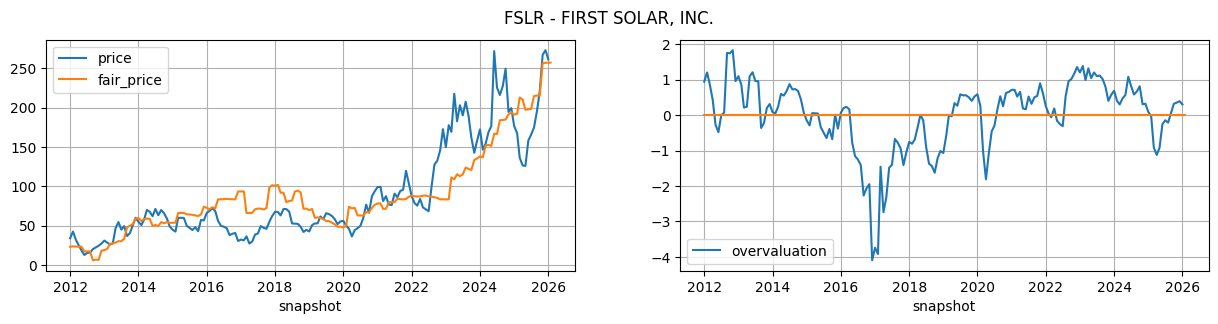

FSLR fair_price = 13.178941 * (2.304709 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -124.615988


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,2.304709,1.542356,13.178941,-124.615988,25.783082,215.177732
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.304709,1.433393,13.178941,-124.615988,28.906791,256.344909
2025-12-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.304709,1.464224,13.178941,-124.615988,28.956929,257.005669
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.304709,1.470916,13.178941,-124.615988,28.967812,257.149099
2026-01-24,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.304709,1.470916,13.178941,-124.615988,28.967812,257.149099


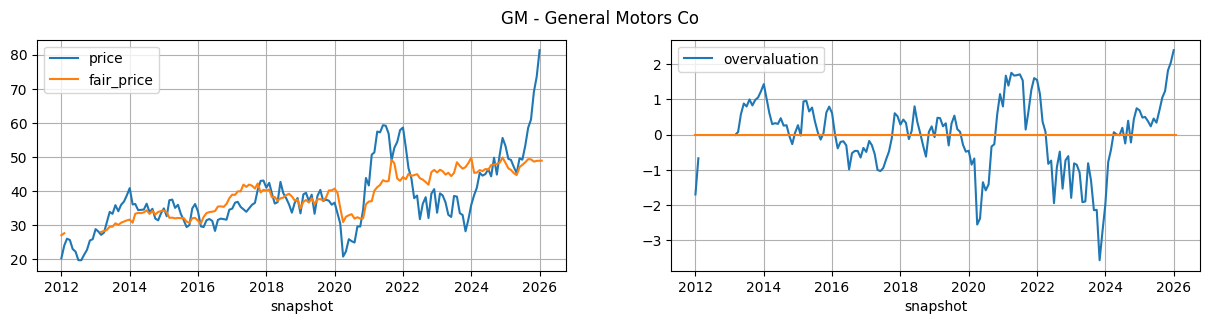

GM fair_price = 0.303048 * (0.984209 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +19.380338


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001467858,2025-06-30,GM,289.384,223.021,23.970,0.984209,1.542356,0.303048,19.380338,98.763583,49.310397
2025-11-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.984209,1.433393,0.303048,19.380338,96.528828,48.633160
2025-12-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.984209,1.464224,0.303048,19.380338,97.275307,48.859379
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.984209,1.470916,0.303048,19.380338,97.437344,48.908484
2026-01-24,0001467858,2025-09-30,GM,288.168,221.794,24.212,0.984209,1.470916,0.303048,19.380338,97.437344,48.908484


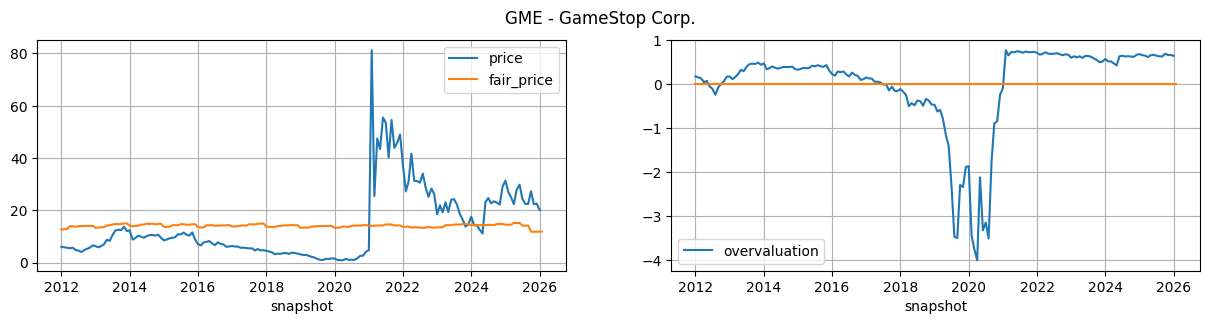

GME fair_price = 0.907046 * (0.000138 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +15.814051


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000138,1.542356,0.907046,15.814051,-4.397034,11.825738
2025-11-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000138,1.433393,0.907046,15.814051,-4.451167,11.776638
2025-12-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000138,1.464224,0.907046,15.814051,-4.435850,11.790531
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000138,1.470916,0.907046,15.814051,-4.387968,11.833962
2026-01-24,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000138,1.470916,0.907046,15.814051,-4.387968,11.833962


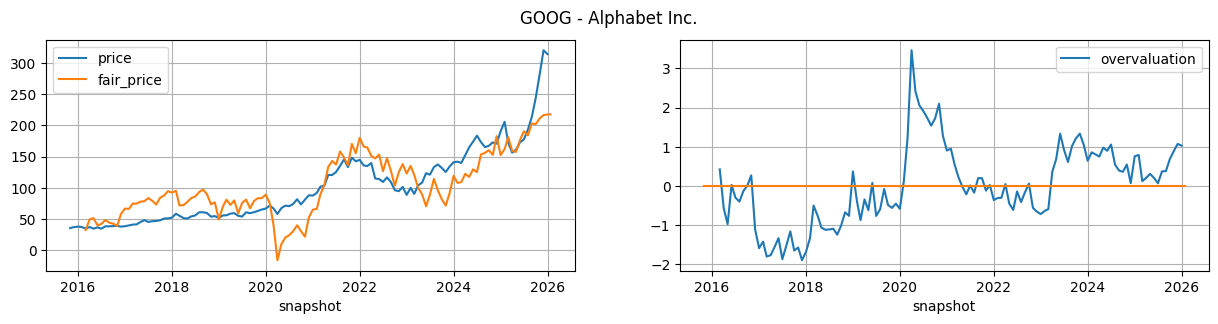

GOOG fair_price = 1.126263 * (0.225704 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -1.314181


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001652044,2025-06-30,GOOG,502.053,139.137,133.708,0.225704,1.542356,1.126263,-1.314181,180.403704,201.867893
2025-11-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.225704,1.433393,1.126263,-1.314181,188.531329,211.021738
2025-12-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.225704,1.464224,1.126263,-1.314181,193.199879,216.279755
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.225704,1.470916,1.126263,-1.314181,194.213270,217.421101
2026-01-24,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.225704,1.470916,1.126263,-1.314181,194.213270,217.421101


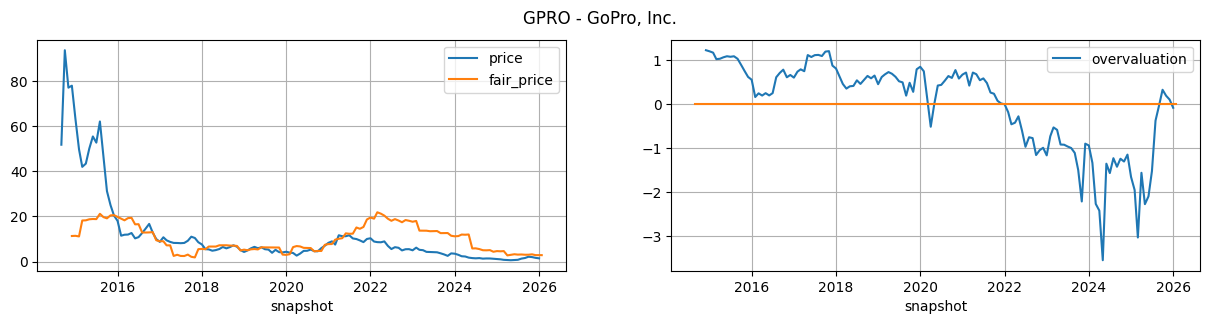

GPRO fair_price = 20.504754 * (0.814961 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.071148


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.814961,1.542356,20.504754,5.071148,-0.100190,3.016774
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.814961,1.433393,20.504754,5.071148,-0.091933,3.186079
2025-12-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.814961,1.464224,20.504754,5.071148,-0.109030,2.835512
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.814961,1.470916,20.504754,5.071148,-0.109441,2.827090
2026-01-24,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.814961,1.470916,20.504754,5.071148,-0.109441,2.827090


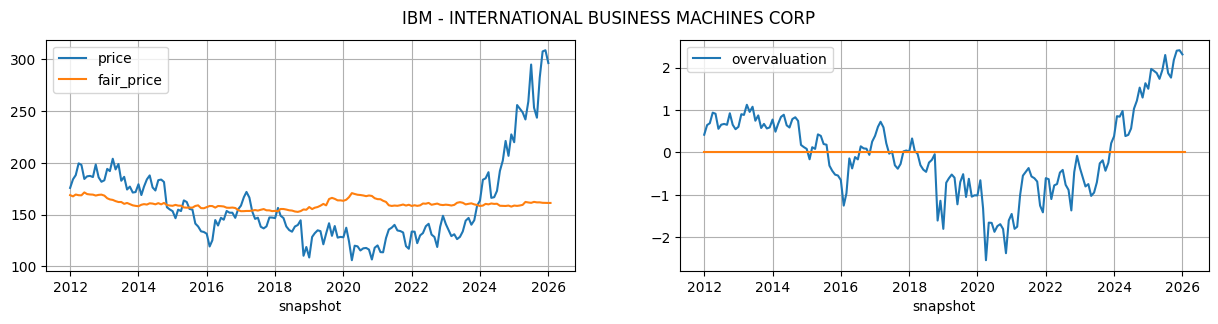

IBM fair_price = -0.288130 * (0.003504 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +133.024686


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000051143,2025-06-30,IBM,148.585,121.076,13.282,0.003504,1.542356,-0.28813,133.024686,-100.069847,161.857772
2025-11-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003504,1.433393,-0.28813,133.024686,-98.567942,161.425029
2025-12-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003504,1.464224,-0.28813,133.024686,-98.152248,161.305255
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003504,1.470916,-0.28813,133.024686,-98.062014,161.279256
2026-01-24,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.003504,1.470916,-0.28813,133.024686,-98.062014,161.279256


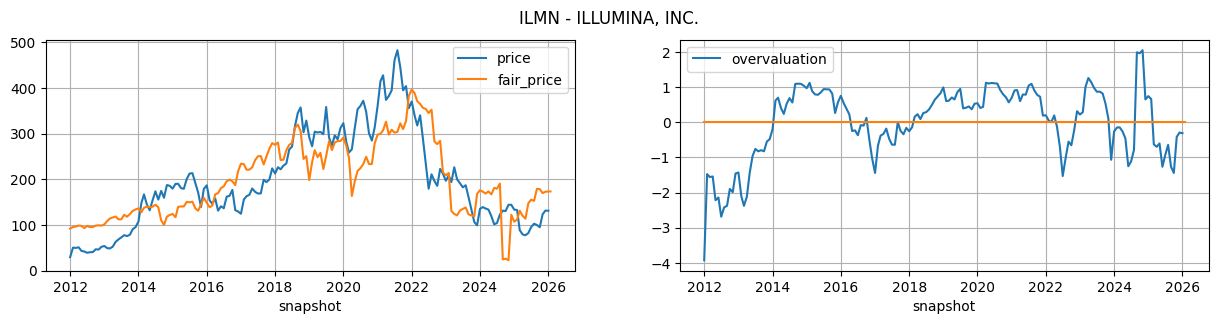

ILMN fair_price = 85.135243 * (0.400112 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +145.601773


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001110803,2025-06-29,ILMN,6.087,3.829,1.154,0.400112,1.542356,85.135243,145.601773,0.386362,178.494799
2025-11-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400112,1.433393,85.135243,145.601773,0.283761,169.759796
2025-12-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400112,1.464224,85.135243,145.601773,0.318353,172.704825
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400112,1.470916,85.135243,145.601773,0.325862,173.344095
2026-01-24,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.400112,1.470916,85.135243,145.601773,0.325862,173.344095


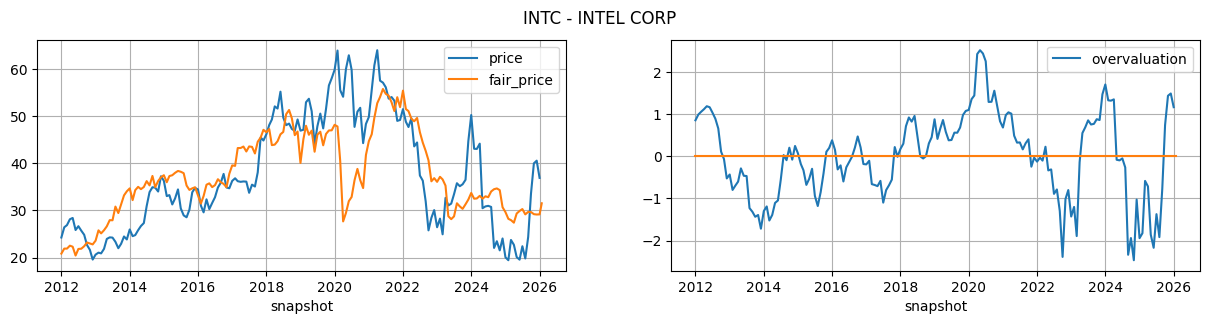

INTC fair_price = 0.416433 * (0.436301 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +27.614272


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.436301,1.542356,0.416433,27.614272,4.909724,29.658845
2025-11-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.436301,1.433393,0.416433,27.614272,3.811162,29.201367
2025-12-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.436301,1.464224,0.416433,27.614272,3.645946,29.132566
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.436301,1.470916,0.416433,27.614272,3.703327,29.156461
2026-01-24,0000050863,2025-12-27,INTC,211.429,97.148,9.697,0.436301,1.470916,0.416433,27.614272,9.362188,31.513000


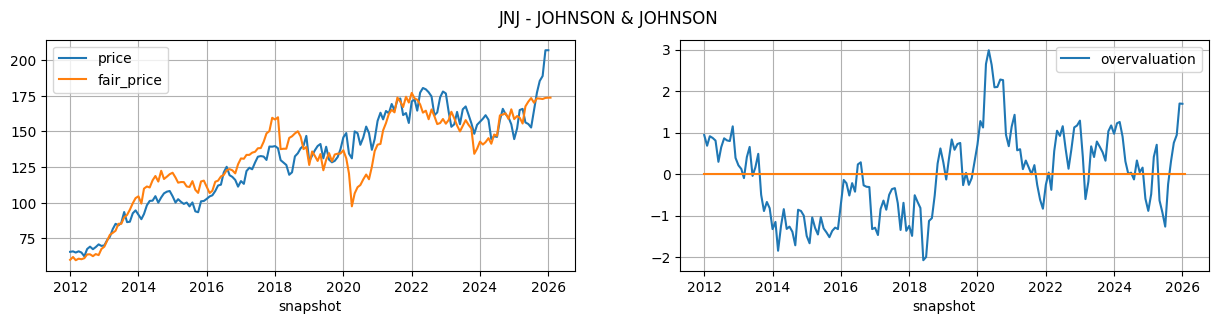

JNJ fair_price = 1.061575 * (1.457775 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -41.955152


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000200406,2025-06-29,JNJ,193.389,114.916,23.028,1.457775,1.542356,1.061575,-41.955152,202.519012,173.033980
2025-11-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.457775,1.433393,1.061575,-41.955152,202.237182,172.734797
2025-12-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.457775,1.464224,1.061575,-41.955152,202.983415,173.526979
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.457775,1.470916,1.061575,-41.955152,203.145398,173.698936
2026-01-24,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.457775,1.470916,1.061575,-41.955152,203.145398,173.698936


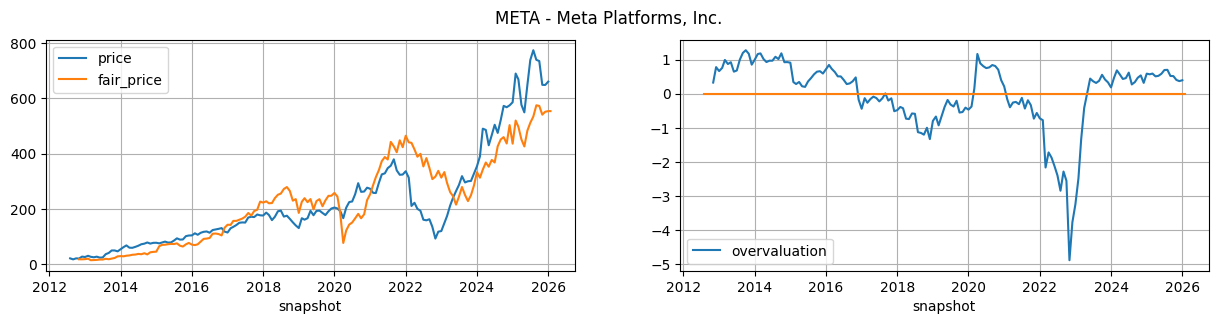

META fair_price = 3.161935 * (0.406701 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +9.554583


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001326801,2025-06-30,META,294.744,99.674,102.299,0.406701,1.542356,3.161935,9.554583,177.980126,572.316254
2025-11-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.406701,1.433393,3.161935,9.554583,167.991469,540.732767
2025-12-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.406701,1.464224,3.161935,9.554583,171.308081,551.219679
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.406701,1.470916,3.161935,9.554583,172.028010,553.496049
2026-01-24,0001326801,2025-09-30,META,303.844,109.778,107.574,0.406701,1.470916,3.161935,9.554583,172.028010,553.496049


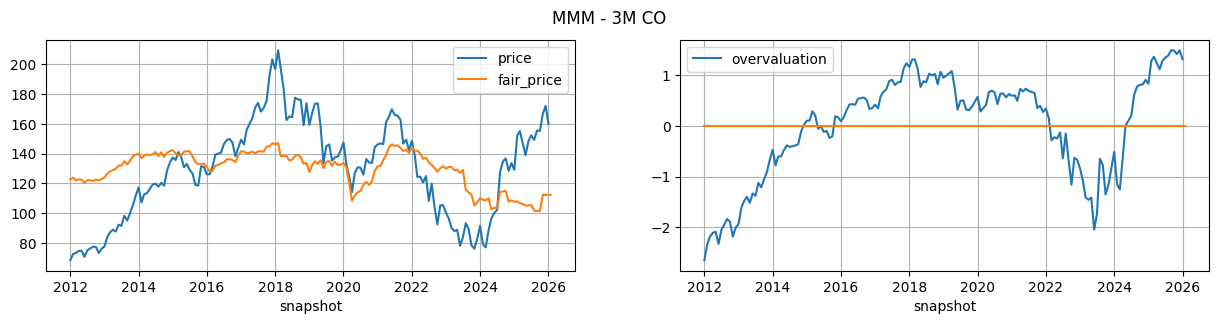

MMM fair_price = 1.861924 * (0.481668 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +132.982100


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000066740,2025-06-30,MMM,37.989,33.699,-1.002,0.481668,1.542356,1.861924,132.9821,-16.946357,101.429263
2025-11-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.481668,1.433393,1.861924,132.9821,-11.224736,112.082489
2025-12-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.481668,1.464224,1.861924,132.9821,-11.146395,112.228355
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.481668,1.470916,1.861924,132.9821,-11.129389,112.260018
2026-01-24,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.481668,1.470916,1.861924,132.9821,-11.129389,112.260018


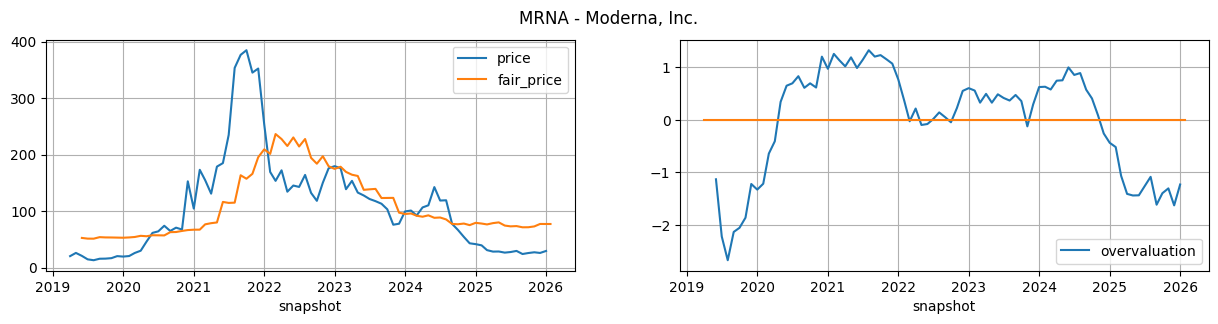

MRNA fair_price = 4.914522 * (0.906729 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +51.239881


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.906729,1.542356,4.914522,51.239881,4.119086,71.483217
2025-11-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,0.906729,1.433393,4.914522,51.239881,4.412958,72.927460
2025-12-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.906729,1.464224,4.914522,51.239881,5.301925,77.296307
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.906729,1.470916,4.914522,51.239881,5.288688,77.231250
2026-01-24,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,0.906729,1.470916,4.914522,51.239881,5.288688,77.231250


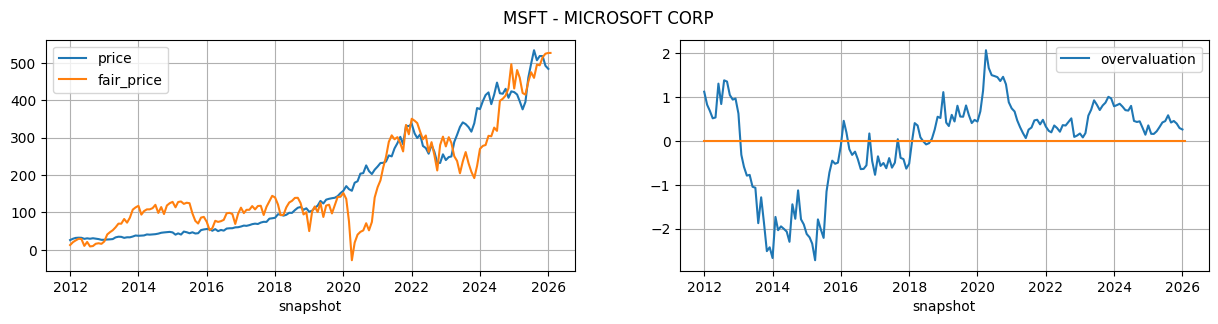

MSFT fair_price = 2.074921 * (0.426211 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +81.724163


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000789019,2025-06-30,MSFT,619.003,275.524,136.162,0.426211,1.542356,2.074921,81.724163,198.312231,493.206290
2025-11-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.426211,1.433393,2.074921,81.724163,208.709567,514.779936
2025-12-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.426211,1.464224,2.074921,81.724163,213.242923,524.186290
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.426211,1.470916,2.074921,81.724163,214.226969,526.228106
2026-01-24,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.426211,1.470916,2.074921,81.724163,214.226969,526.228106


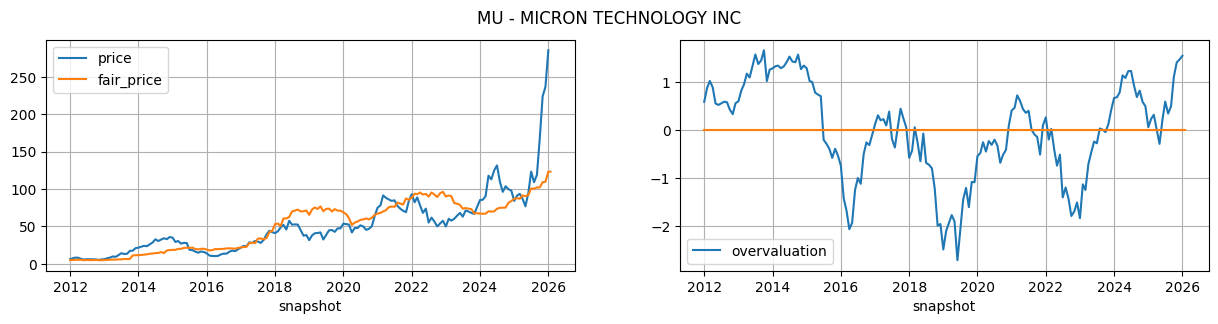

MU fair_price = 0.977514 * (1.481222 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -7.296303


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000723125,2025-05-29,MU,78.397,27.649,15.200,1.481222,1.542356,0.977514,-7.296303,111.918168,102.105217
2025-11-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.481222,1.433393,0.977514,-7.296303,119.129430,109.154324
2025-12-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,1.481222,1.464224,0.977514,-7.296303,119.669743,109.682487
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.481222,1.470916,0.977514,-7.296303,133.555169,123.255678
2026-01-24,0000723125,2025-11-27,MU,85.971,27.165,22.692,1.481222,1.470916,0.977514,-7.296303,133.555169,123.255678


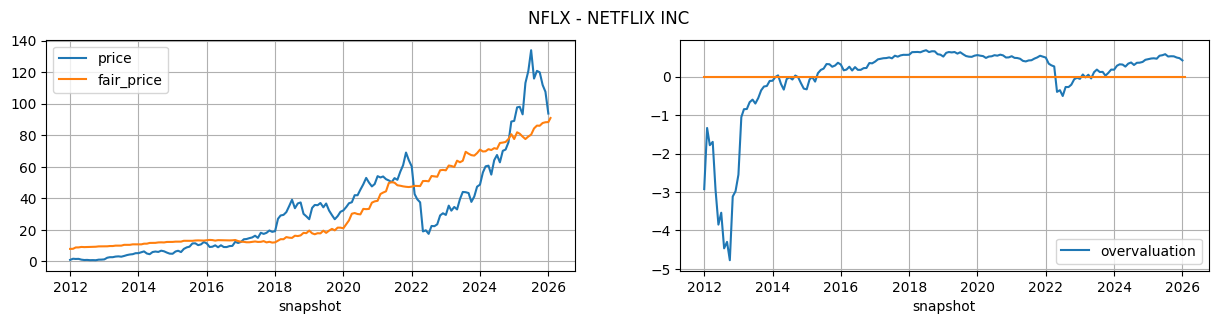

NFLX fair_price = 1.585181 * (1.201383 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +7.346038


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,1.201383,1.542356,1.585181,7.346038,49.635124,86.026698
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.201383,1.433393,1.585181,7.346038,50.741025,87.779751
2025-12-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.201383,1.464224,1.585181,7.346038,51.036217,88.247684
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.201383,1.470916,1.585181,7.346038,51.100294,88.349257
2026-01-24,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,1.201383,1.470916,1.585181,7.346038,52.740500,90.949281


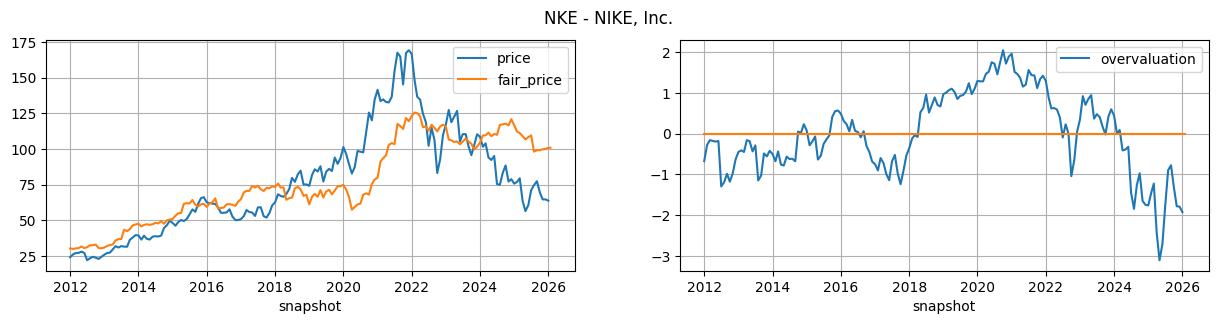

NKE fair_price = 2.199530 * (1.935081 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -17.784105


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000320187,2025-05-31,NKE,36.579,23.366,3.698,1.935081,1.542356,2.19953,-17.784105,53.120972,99.057080
2025-11-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,1.935081,1.433393,2.19953,-17.784105,53.432470,99.742230
2025-12-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,1.935081,1.464224,2.19953,-17.784105,53.541181,99.981341
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,1.935081,1.470916,2.19953,-17.784105,53.914039,100.801455
2026-01-24,0000320187,2025-11-30,NKE,37.787,23.702,3.056,1.935081,1.470916,2.19953,-17.784105,53.914039,100.801455


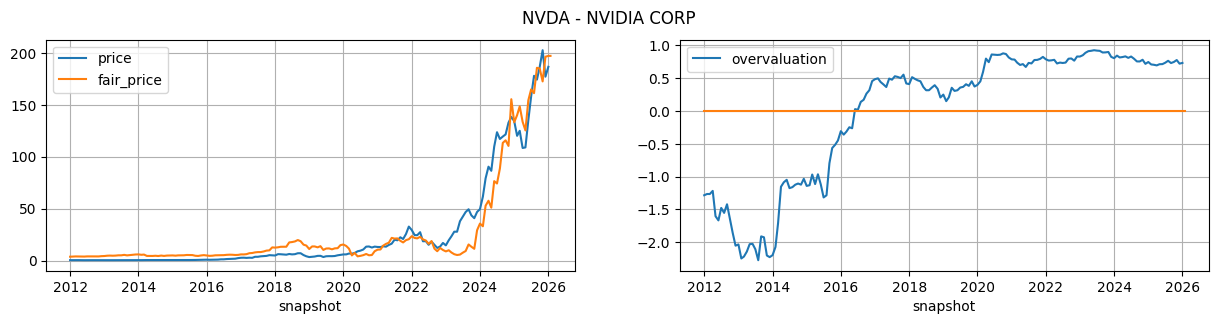

NVDA fair_price = 1.471083 * (0.315235 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +4.516430


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.315235,1.542356,1.471083,4.51643,122.572481,184.830722
2025-11-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.315235,1.433393,1.471083,4.51643,114.178534,172.482529
2025-12-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.315235,1.464224,1.471083,4.51643,130.311813,196.215921
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.315235,1.470916,1.471083,4.51643,130.868347,197.034629
2026-01-24,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.315235,1.470916,1.471083,4.51643,130.868347,197.034629


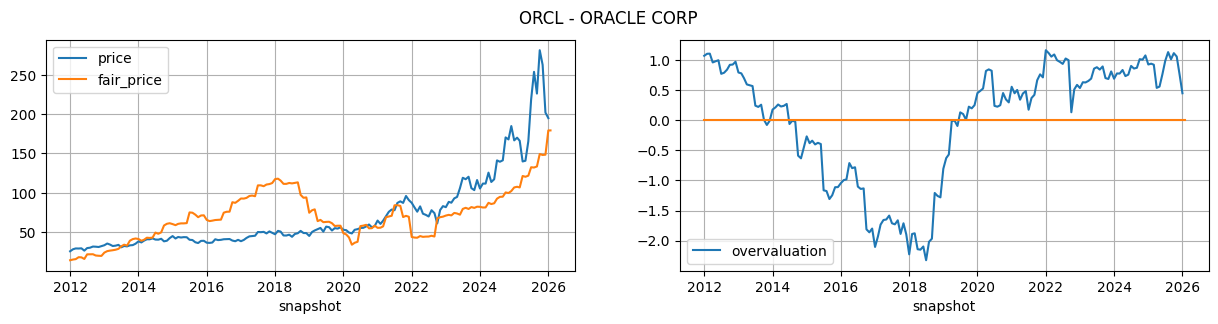

ORCL fair_price = 0.516597 * (3.147825 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -80.559384


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.147825,1.542356,0.516597,-80.559384,444.940044,149.295428
2025-11-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.147825,1.433393,0.516597,-80.559384,442.593640,148.083282
2025-12-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.147825,1.464224,0.516597,-80.559384,443.257554,148.426258
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.147825,1.470916,0.516597,-80.559384,503.016405,179.297517
2026-01-24,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.147825,1.470916,0.516597,-80.559384,503.016405,179.297517


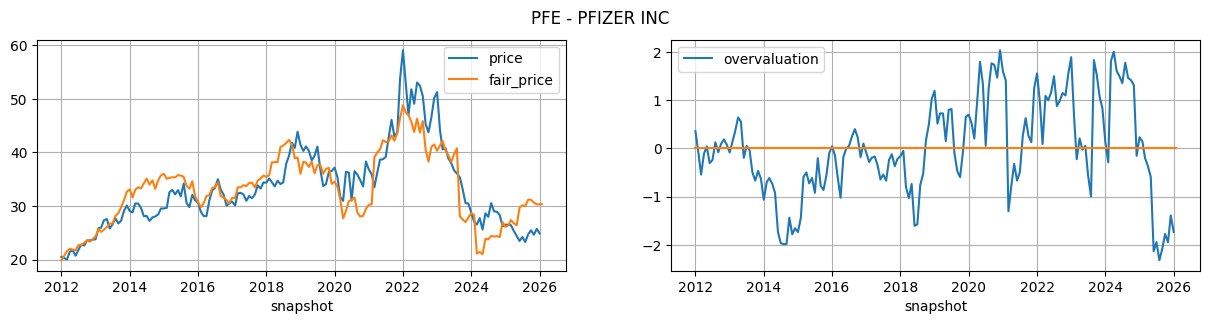

PFE fair_price = 0.309352 * (0.014477 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +59.320194


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.014477,1.542356,0.309352,59.320194,-90.991121,31.171929
2025-11-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.014477,1.433393,0.309352,59.320194,-92.646048,30.659975
2025-12-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.014477,1.464224,0.309352,59.320194,-93.760603,30.315185
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.014477,1.470916,0.309352,59.320194,-93.673086,30.342259
2026-01-24,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.014477,1.470916,0.309352,59.320194,-93.673086,30.342259


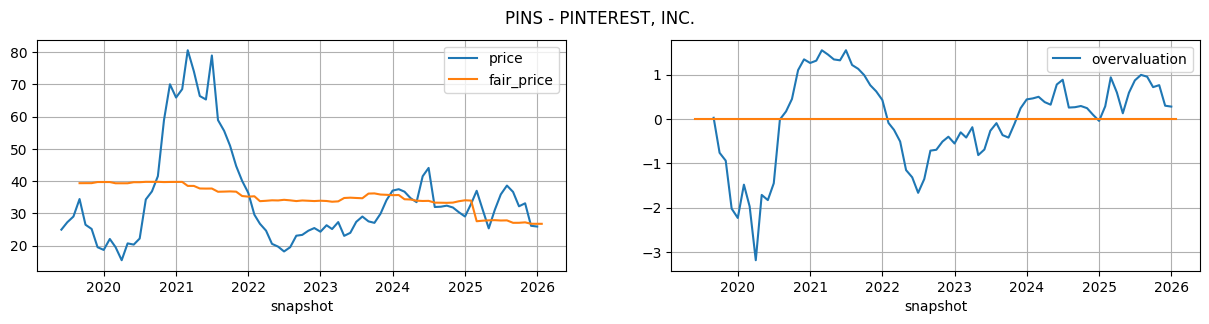

PINS fair_price = -1.183160 * (2.966767 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.274322


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,2.966767,1.542356,-1.18316,47.274322,17.093967,27.049428
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,2.966767,1.433393,-1.18316,47.274322,16.977004,27.187813
2025-12-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,2.966767,1.464224,-1.18316,47.274322,17.352027,26.744101
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,2.966767,1.470916,-1.18316,47.274322,17.359703,26.735019
2026-01-24,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,2.966767,1.470916,-1.18316,47.274322,17.359703,26.735019


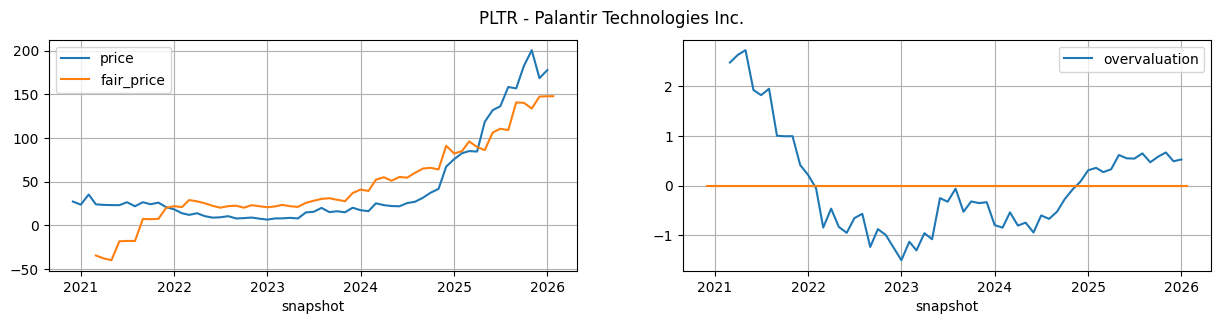

PLTR fair_price = 35.027219 * (0.394956 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.749036


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.394956,1.542356,35.027219,-4.749036,4.140013,140.264110
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.394956,1.433393,35.027219,-4.749036,3.951550,133.662761
2025-12-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.394956,1.464224,35.027219,-4.749036,4.342387,147.352717
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.394956,1.470916,35.027219,-4.749036,4.354551,147.778770
2026-01-24,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.394956,1.470916,35.027219,-4.749036,4.354551,147.778770


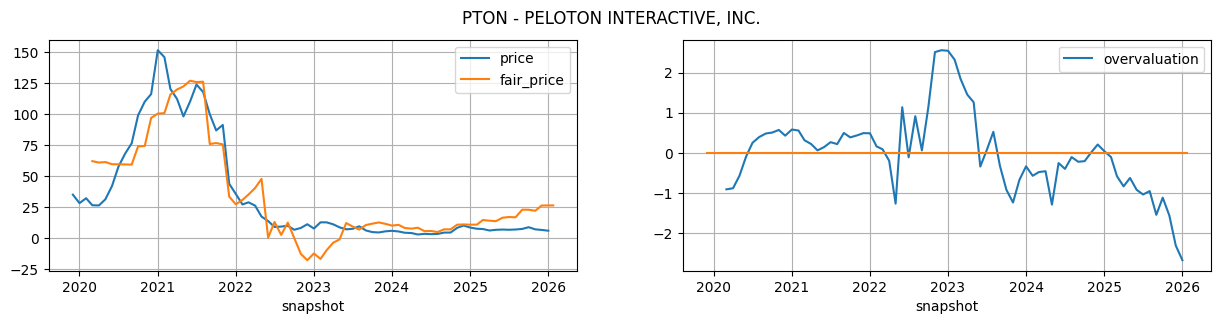

PTON fair_price = 22.863703 * (1.476471 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.347066


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.476471,1.542356,22.863703,-2.347066,1.112448,23.087605
2025-11-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.476471,1.433393,22.863703,-2.347066,1.076163,22.258005
2025-12-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.476471,1.464224,22.863703,-2.347066,1.261550,26.496649
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.476471,1.470916,22.863703,-2.347066,1.264177,26.556692
2026-01-24,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.476471,1.470916,22.863703,-2.347066,1.264177,26.556692


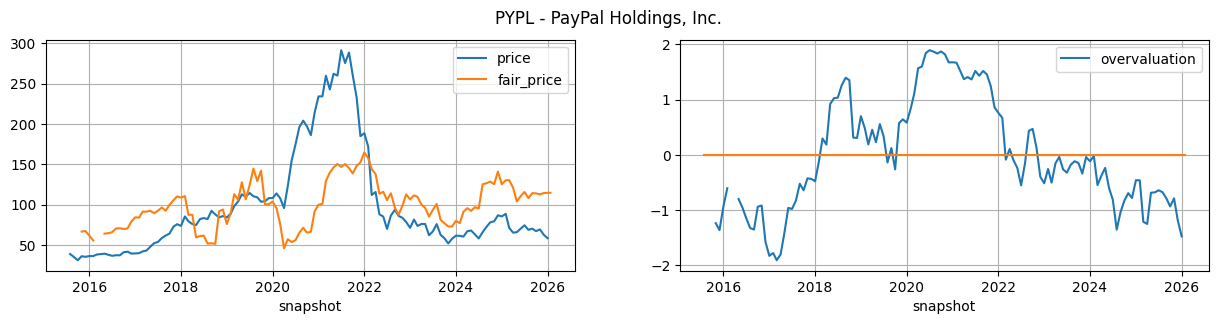

PYPL fair_price = 7.992610 * (0.851746 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -27.780123


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001633917,2025-06-30,PYPL,79.777,59.576,6.066,0.851746,1.542356,7.99261,-27.780123,17.729638,113.925952
2025-11-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.851746,1.433393,7.99261,-27.780123,17.578133,112.715033
2025-12-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.851746,1.464224,7.99261,-27.780123,17.776253,114.298528
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.851746,1.470916,7.99261,-27.780123,17.819258,114.642253
2026-01-24,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.851746,1.470916,7.99261,-27.780123,17.819258,114.642253


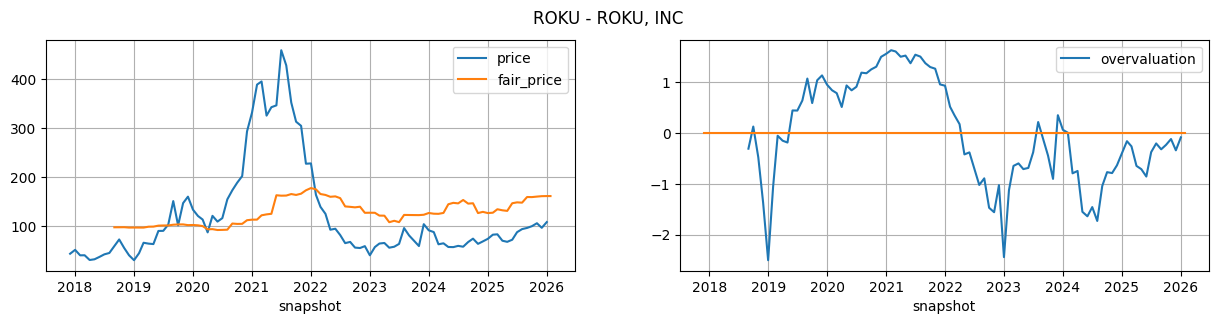

ROKU fair_price = 62.376672 * (0.484249 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +97.513567


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.484249,1.542356,62.376672,97.513567,0.993551,159.487950
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.484249,1.433393,62.376672,97.513567,1.009891,160.507186
2025-12-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.484249,1.464224,62.376672,97.513567,1.023930,161.382904
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.484249,1.470916,62.376672,97.513567,1.026977,161.572994
2026-01-24,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.484249,1.470916,62.376672,97.513567,1.026977,161.572994


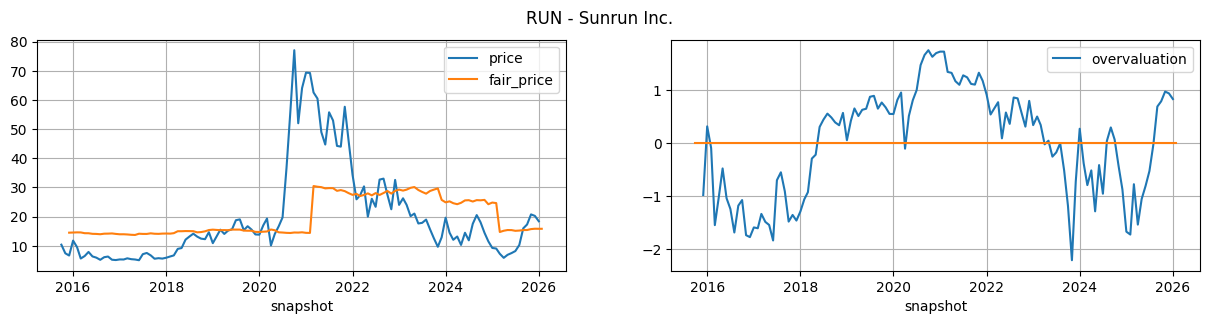

RUN fair_price = 3.570946 * (0.950960 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.137125


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.95096,1.542356,3.570946,13.137125,0.634171,15.401714
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.95096,1.433393,3.570946,13.137125,0.722581,15.717422
2025-12-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.95096,1.464224,3.570946,13.137125,0.756639,15.839042
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.95096,1.470916,3.570946,13.137125,0.751441,15.820480
2026-01-24,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.95096,1.470916,3.570946,13.137125,0.751441,15.820480


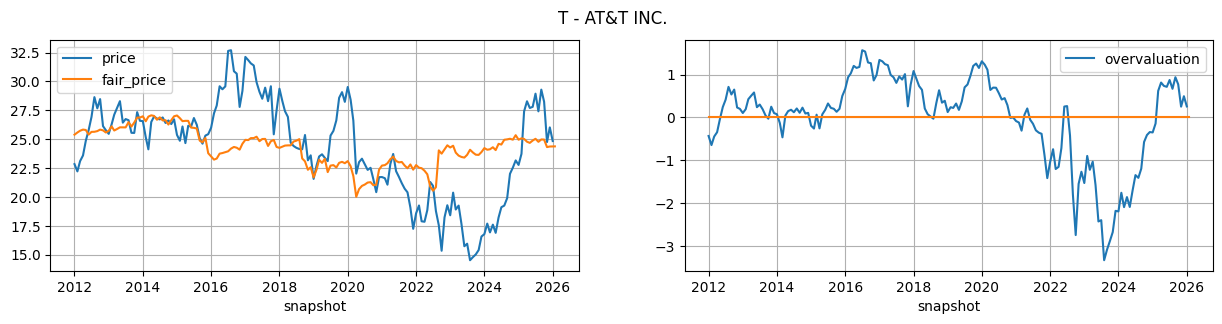

T fair_price = 0.039851 * (0.034628 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.209767


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732717,2025-06-30,T,405.491,284.097,40.943,0.034628,1.542356,0.039851,33.209767,-206.906818,24.964422
2025-11-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.034628,1.433393,0.039851,33.209767,-223.234367,24.313761
2025-12-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.034628,1.464224,0.039851,33.209767,-221.974614,24.363962
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.034628,1.470916,0.039851,33.209767,-221.701162,24.374860
2026-01-24,0000732717,2025-09-30,T,423.213,296.458,40.860,0.034628,1.470916,0.039851,33.209767,-221.701162,24.374860


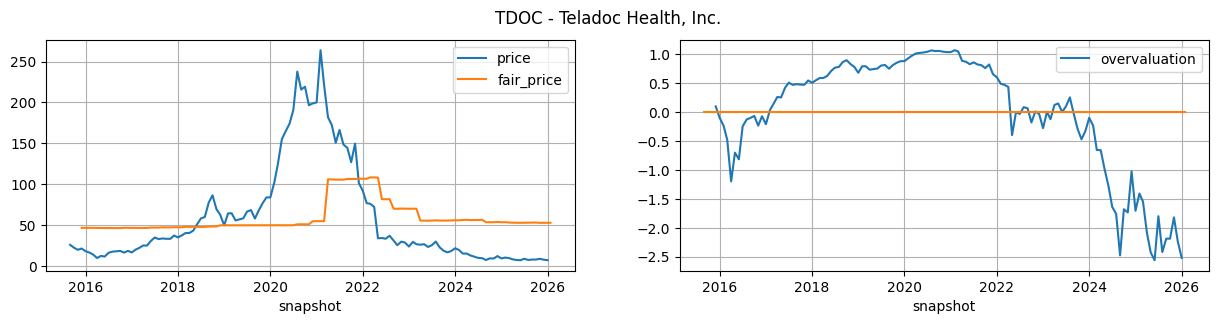

TDOC fair_price = 3.941282 * (0.967279 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.887213


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,0.967279,1.542356,3.941282,45.887213,1.795439,52.963543
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.967279,1.433393,3.941282,45.887213,1.717218,52.655255
2025-12-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.967279,1.464224,3.941282,45.887213,1.726237,52.690800
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.967279,1.470916,3.941282,45.887213,1.728195,52.698515
2026-01-24,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,0.967279,1.470916,3.941282,45.887213,1.728195,52.698515


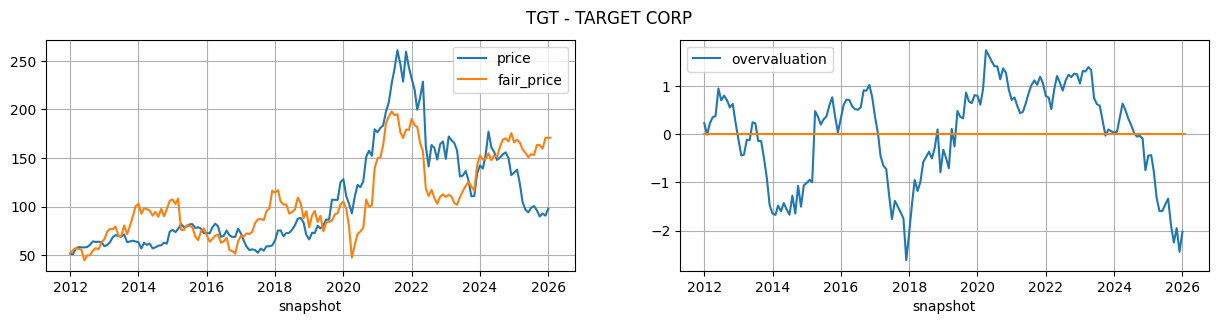

TGT fair_price = 5.114757 * (1.604844 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -144.939523


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.604844,1.542356,5.114757,-144.939523,60.260339,163.277484
2025-11-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.604844,1.433393,5.114757,-144.939523,59.564503,159.718450
2025-12-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.604844,1.464224,5.114757,-144.939523,61.704875,170.665936
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.604844,1.470916,5.114757,-144.939523,61.750209,170.897811
2026-01-24,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.604844,1.470916,5.114757,-144.939523,61.750209,170.897811


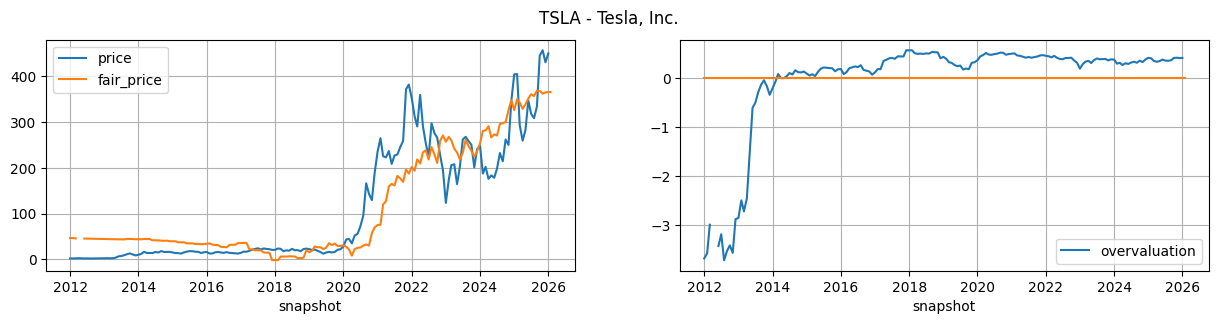

TSLA fair_price = 5.988510 * (0.628521 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.065090


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001318605,2025-06-30,TSLA,128.567,51.253,15.765,0.628521,1.542356,5.98851,45.06509,53.869305,367.661980
2025-11-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.628521,1.433393,5.98851,45.06509,52.863337,361.637725
2025-12-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.628521,1.464224,5.98851,45.06509,53.348863,364.545304
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.628521,1.470916,5.98851,45.06509,53.454255,365.176446
2026-01-24,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.628521,1.470916,5.98851,45.06509,53.454255,365.176446


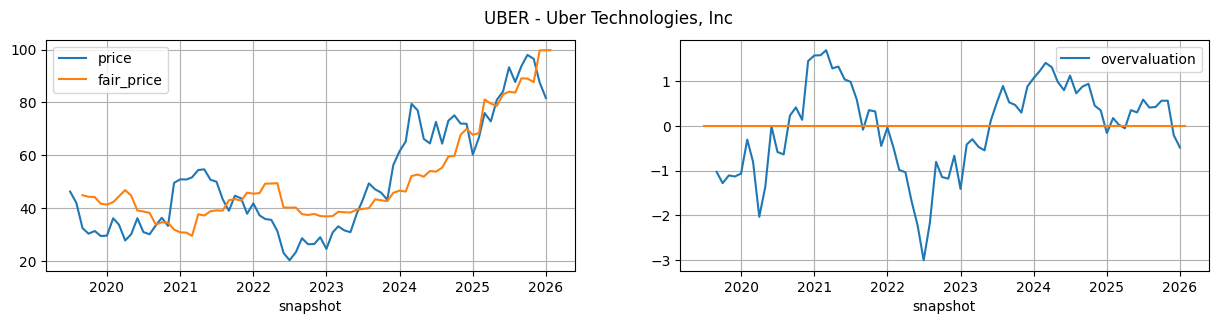

UBER fair_price = 1.402989 * (1.334208 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +12.058702


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.334208,1.542356,1.402989,12.058702,54.863369,89.031429
2025-11-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.334208,1.433393,1.402989,12.058702,53.905695,87.687822
2025-12-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.334208,1.464224,1.402989,12.058702,62.432272,99.650520
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.334208,1.470916,1.402989,12.058702,62.492276,99.734705
2026-01-24,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.334208,1.470916,1.402989,12.058702,62.492276,99.734705


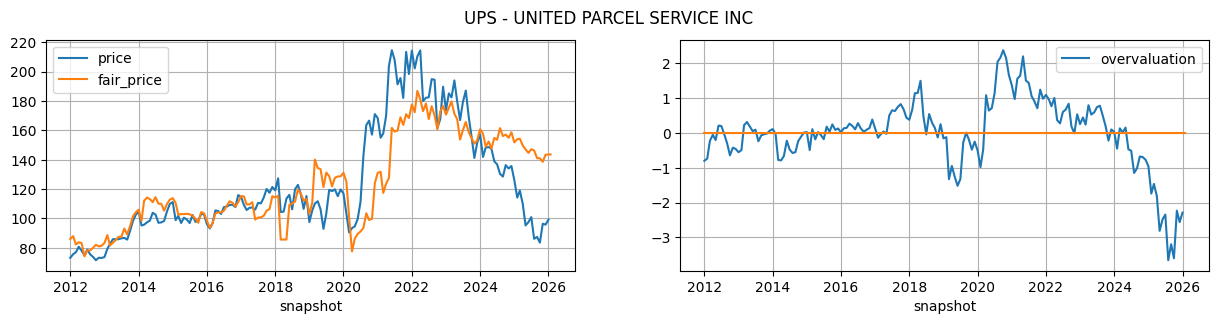

UPS fair_price = 2.922884 * (0.812509 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +100.089948


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.812509,1.542356,2.922884,100.089948,13.987870,140.974870
2025-11-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.812509,1.433393,2.922884,100.089948,13.172937,138.592917
2025-12-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.812509,1.464224,2.922884,100.089948,14.829385,143.434522
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.812509,1.470916,2.922884,100.089948,14.886023,143.600068
2026-01-24,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.812509,1.470916,2.922884,100.089948,14.886023,143.600068


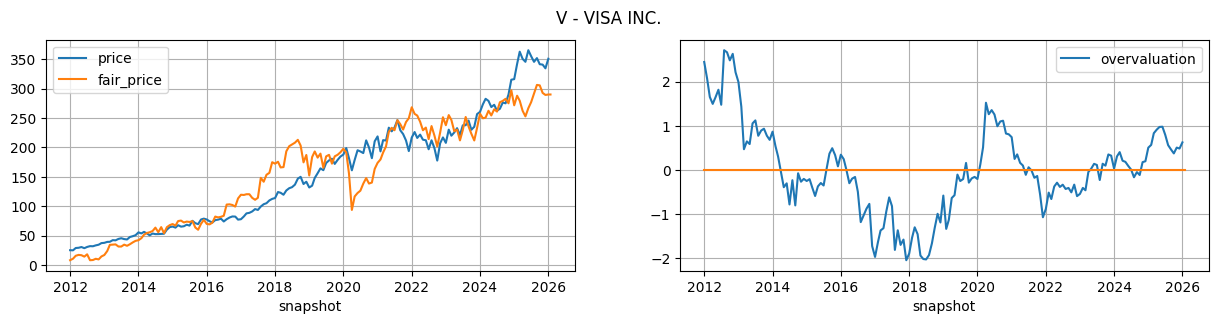

V fair_price = 5.000686 * (1.100294 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -119.187865


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.100294,1.542356,5.000686,-119.187865,84.917979,305.460292
2025-11-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.100294,1.433393,5.000686,-119.187865,82.358988,292.663582
2025-12-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.100294,1.464224,5.000686,-119.187865,81.664478,289.190554
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.100294,1.470916,5.000686,-119.187865,81.818798,289.962261
2026-01-24,0001403161,2025-09-30,V,99.627,61.718,23.059,1.100294,1.470916,5.000686,-119.187865,81.818798,289.962261


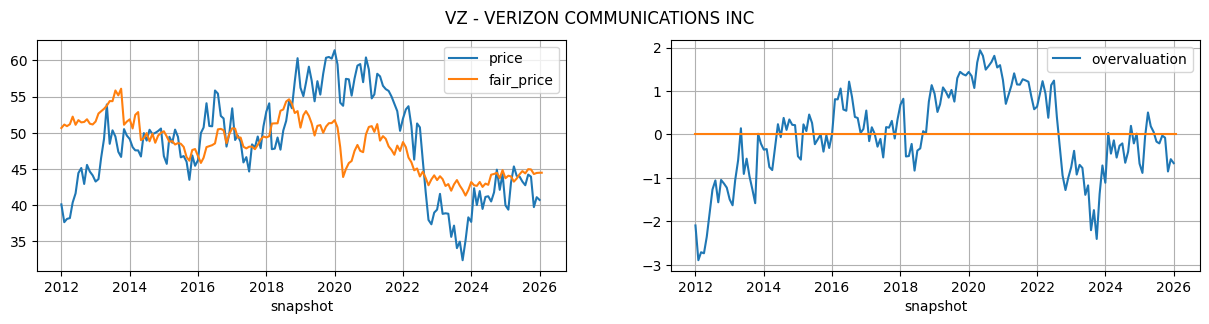

VZ fair_price = 0.124365 * (0.008753 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +72.101687


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,0.008753,1.542356,0.124365,72.101687,-218.347829,44.946834
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.008753,1.433393,0.124365,72.101687,-223.465935,44.310320
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.008753,1.464224,0.124365,72.101687,-222.280329,44.457768
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.008753,1.470916,0.124365,72.101687,-222.022973,44.489774
2026-01-24,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.008753,1.470916,0.124365,72.101687,-222.022973,44.489774


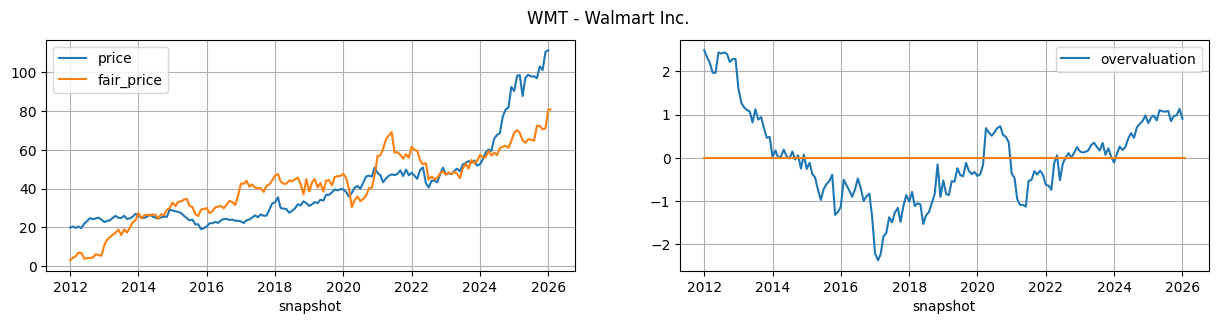

WMT fair_price = 0.412821 * (1.766372 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -75.030944


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.766372,1.542356,0.412821,-75.030944,356.956882,72.328275
2025-11-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.766372,1.433393,0.412821,-75.030944,352.768570,70.599253
2025-12-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.766372,1.464224,0.412821,-75.030944,353.953652,71.088480
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.766372,1.470916,0.412821,-75.030944,377.584762,80.843893
2026-01-24,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.766372,1.470916,0.412821,-75.030944,377.584762,80.843893


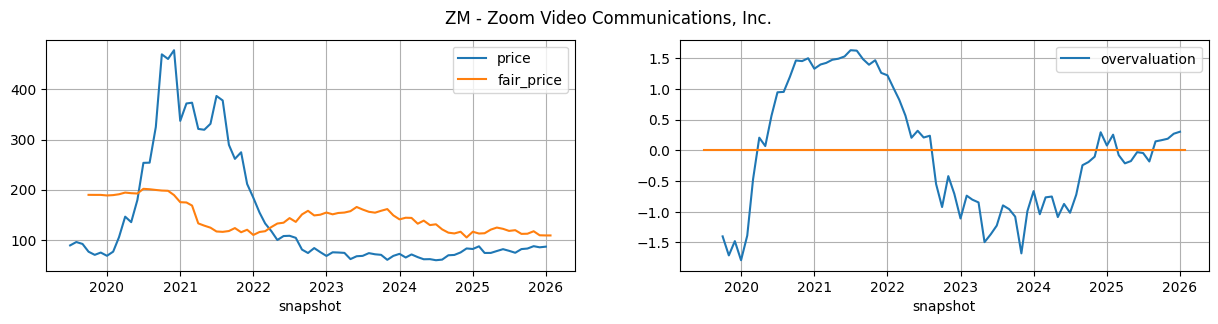

ZM fair_price = -23.711683 * (0.220391 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +190.100230


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,slope,intercept,fair_model,fair_price
snapshot,cik,,,,,,,,,,,
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.220391,1.542356,-23.711683,190.10023,3.290525,112.076335
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.220391,1.433393,-23.711683,190.10023,3.082081,117.018894
2025-12-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.220391,1.464224,-23.711683,190.10023,3.421432,108.972322
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.220391,1.470916,-23.711683,190.10023,3.435212,108.645568
2026-01-24,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.220391,1.470916,-23.711683,190.10023,3.435212,108.645568


In [18]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['fair_model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']
    df['fair_price'] = df['fair_model'] * df['slope'] + df['intercept']
    df['overvaluation'] = -1 * preprocessing.scale(df['fair_price']/df['price'])

    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    df[['price','fair_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} fair_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, df['slope'].mean(), df['asmul'].mean(),
        "+" if df['intercept'].mean() >= 0 else "", df['intercept'].mean()
    ))

    # Display a few most recent records from the resultset
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(5).dropna(axis='columns'))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [19]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

               price  fair_price
price       1.000000    0.915825
fair_price  0.915825    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,slope,intercept,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.008753,-1.138447,-172.402422,0.124365,72.101687,-172.402422,50.660840,-2.093771
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.008753,-1.009673,-168.569967,0.124365,72.101687,-168.569967,51.137464,-2.894185
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.008753,-0.932981,-170.320019,0.124365,72.101687,-170.320019,50.919818,-2.711246
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.008753,-0.861563,-168.193185,0.124365,72.101687,-168.193185,51.184322,-2.734170
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.008753,-0.886716,-159.772784,0.124365,72.101687,-159.772784,52.231526,-2.352617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,43.95,0.008753,1.542356,-218.347829,0.124365,72.101687,-218.347829,44.946834,-0.074199
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,39.74,0.008753,1.433393,-223.465935,0.124365,72.101687,-223.465935,44.310320,-0.850931
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,41.11,0.008753,1.464224,-222.280329,0.124365,72.101687,-222.280329,44.457768,-0.568495


All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

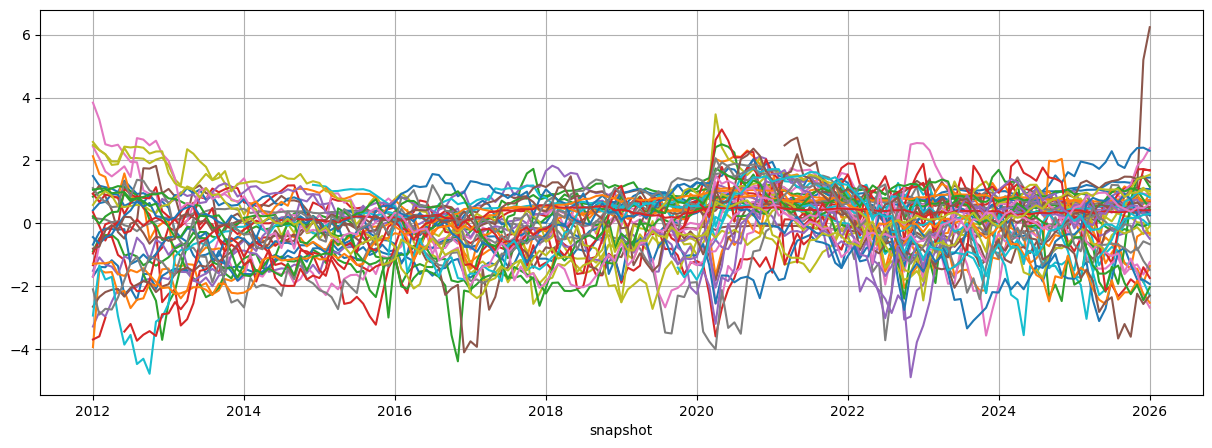

In [20]:
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='overvaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [21]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.